# Решающий слой: EDA признаков и обучение с подбором гиперпараметров

Решающий слой получает для каждого запроса список кандидатов (визуальный поиск SigLIP 2 +
текстовая ветка + расширение по винодельне) и для каждой пары «запрос — кандидат» ~60
признаков: визуальные score/ранги, OCR-совпадения, геометрию XFeat/RANSAC. CatBoost оценивает,
верен ли кандидат; лучший по оценке — ответ, калиброванная оценка — основание для отказа.

План ноутбука:

1. **Данные** — признаки, посчитанные пайплайном на индексе `label-square-v3`
   (`scripts/build_platform_features.py`), только synthetic/train, holdout исключён. С
   23.09.2026 в train есть живые кадры знакомых вин — organizer_100 без вин теста
   (`scripts/import_organizer_photos.py`).
2. **EDA** — состав выборки, потолок retrieval, заглушки, одномерная сила признаков,
   избыточность, сдвиг между синтетикой и живыми кадрами, эвристические бейзлайны.
3. **Схема валидации** — `GroupKFold` по винам; вложенная CV: Optuna во внутренних фолдах,
   честная оценка на внешних.
4. **Сравнение моделей** — эвристики, логистическая регрессия, CatBoost с текущими
   параметрами, CatBoost после подбора; bootstrap-интервалы по винам.
5. **Финальная модель** — подбор на всём train; живые кадры делятся по винодельням на
   калибровку (K) и порог (P); интерпретация (SHAP), разбор ошибок, сохранение артефакта.
6. **Тест** — один прогон `eval/platform_benchmark.py` на изолированном `data/test`.

Правило: ничто до раздела 6 не видит `data/test`, `data/eval`, `data/live`. Порог и
гиперпараметры выбираются только по train.


In [1]:
from pathlib import Path
import importlib.util, json, os, subprocess, sys, time, warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT/'pyproject.toml').exists(): ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

from wine_scanner.catalog import is_holdout
from wine_scanner.decide import FEATURE_NAMES, Decider, derive, logit
from wine_scanner.image_preprocess import LABEL_PREPROCESS_VERSION

# Общие функции обучения берём из боевого скрипта, чтобы ноутбук и артефакт не разошлись.
spec = importlib.util.spec_from_file_location('train_decider', ROOT/'scripts/train_decider.py')
TD = importlib.util.module_from_spec(spec); spec.loader.exec_module(TD)

SEED = 2026
INDEX = Path('models/index_platform_sq_v3')
FEATURES = Path('eval/results/features_platform_sq_v3.jsonl')
OUT_DIR = Path('models/decider_platform_sq_v3_live')
TUNING_JSON = Path('eval/results/decider_tuning_sq_v3_live.json')
SPLIT_REPEATS = 50                          # случайных разбиений K/P для оценки разброса
LIVE_WEIGHT, BUDGET = 3.0, 0.10          # как в scripts/rebuild_recognition.py
OUTER_FOLDS, INNER_FOLDS = 5, 3
TRIALS_NESTED, TRIALS_FINAL = 15, 30

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
PALETTE = {'synthetic': '#4C72B0', 'live-known': '#55A868', 'live-unknown': '#DD8452'}


def styled(df, good=(), bad=(), bars=(), precision=3):
    """Таблица с подсветкой: good — зелёный градиент (больше лучше), bad — красный
    (больше хуже), bars — полосы долей и количеств прямо в ячейках."""
    st = df.style.format(precision=precision, na_rep='—', thousands=' ')
    for cols, cmap in ((good, 'Greens'), (bad, 'Reds')):
        cols = [c for c in cols if c in df.columns]
        if cols: st = st.background_gradient(cmap=cmap, subset=cols, axis=0)
    cols = [c for c in bars if c in df.columns]
    if cols: st = st.bar(subset=cols, color='#9ecae1', vmin=0)
    return st.set_table_styles([{'selector': 'th', 'props': 'text-align: left;'}])
print('preprocessing:', LABEL_PREPROCESS_VERSION, '| features:', FEATURES)
print('index config:', json.loads((INDEX/'config.json').read_text(encoding='utf-8'))['weights'])


G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


preprocessing: label-square-v3 | features: eval\results\features_platform_sq_v3.jsonl
index config: models\rtdetr_label_recrop_bf16


## 1. Данные

Одна строка файла — пара «запрос — кандидат». `true_id` запроса — верный slug; у живых
незнакомых вин он начинается с `unknown:`, и у всех их кандидатов метка 0. Производные
признаки (отступы от конкурентов, статистики по списку) считаются функцией `derive()` по всему
списку кандидатов запроса — той же, что и в сервисе.


In [2]:
by_query = TD.load_queries(FEATURES)
holdout = [q for q in by_query if is_holdout(q)]
for q in holdout: del by_query[q]
assert not any(is_holdout(q) for q in by_query)
print('исключено holdout-запросов:', len(holdout))

catalog = pd.read_csv('data/catalog/catalog.csv')
TD.FAMILIES.update(dict(zip(catalog['slug'], catalog['winery'], strict=True)))

queries = sorted(by_query)
Q = pd.DataFrame({
    'query': queries,
    'wine': [by_query[q][0].true_id for q in queries],
    'group': [by_query[q][0].group for q in queries],
    'n_candidates': [len(by_query[q]) for q in queries],
    'true_present': [any(c.label for c in by_query[q]) for q in queries],
})
Q['known'] = ~Q.wine.str.startswith(TD.UNKNOWN_PREFIX)
Q['source'] = np.where(Q.group.eq('synthetic'), 'synthetic',
                       np.where(Q.known, 'live-known', 'live-unknown'))
print(f'запросов {len(Q)}, вин {Q.wine.nunique()}, пар {Q.n_candidates.sum()}')
display(styled(Q.groupby(['source', 'group'])
               .agg(queries=('query', 'size'), wines=('wine', 'nunique')),
               bars=['queries', 'wines']))


исключено holdout-запросов: 0
запросов 543, вин 375, пар 89486


In [3]:
# Кэш матриц: derive() считается один раз на запрос, а не в каждом обучении.
FULL, LABELS, NO_TRUE = {}, {}, {}
started = time.time()
for q in queries:
    rows = derive(by_query[q])
    FULL[q] = np.asarray([[float(r[n]) for n in FEATURE_NAMES] for r in rows])
    LABELS[q] = np.asarray([r['label'] for r in rows])
    without_true = [c for c in by_query[q] if not c.label]
    if len(without_true) < len(by_query[q]):
        NO_TRUE[q] = np.asarray([[float(r[n]) for n in FEATURE_NAMES]
                                 for r in derive(without_true)])
print(f'derive: {time.time() - started:.1f} s')

# Паритет с боевым scripts/train_decider.py: та же матрица, те же веса.
probe = queries[:40]
ref_rows, ref_labels, ref_weights = TD.training_rows(
    [by_query[q] for q in probe], True, LIVE_WEIGHT)

GROUP = dict(zip(Q['query'], Q.group))

def training_matrix(qs, cols, augment=True):
    X, y, w = [], [], []
    for q in qs:
        weight = LIVE_WEIGHT if GROUP[q].startswith('live-') else 1.0
        X.append(FULL[q][:, cols]); y.append(LABELS[q]); w.append(np.full(len(LABELS[q]), weight))
        if augment and q in NO_TRUE:
            X.append(NO_TRUE[q][:, cols]); y.append(np.zeros(len(NO_TRUE[q]), int))
            w.append(np.full(len(NO_TRUE[q]), weight))
    return np.vstack(X), np.concatenate(y), np.concatenate(w)

ALL = list(range(len(FEATURE_NAMES)))
X_probe, y_probe, w_probe = training_matrix(probe, ALL)
assert np.allclose(X_probe, np.asarray(ref_rows)) and (y_probe == np.asarray(ref_labels)).all()
assert np.allclose(w_probe, np.asarray(ref_weights))
print('training_matrix совпадает с train_decider.training_rows')

PAIRS = pd.DataFrame(np.vstack([FULL[q] for q in queries]), columns=FEATURE_NAMES)
PAIRS['label'] = np.concatenate([LABELS[q] for q in queries])
PAIRS['query'] = np.repeat(queries, [len(LABELS[q]) for q in queries])
PAIRS = PAIRS.merge(Q[['query', 'wine', 'group', 'source', 'known']], on='query')
print(PAIRS.shape)


derive: 10.6 s


training_matrix совпадает с train_decider.training_rows
(89486, 64)


## 2. EDA

### 2.1 Состав выборки

Знакомые вина в train — в основном **синтетика** (псевдофото из вырезок каталога). Живые
знакомые кадры — organizer_100 (без вин теста) и Chateau Tamagne; живые незнакомые — своя
съёмка импорта, российская полка и незнакомцы organizer_100. Тест состоит из живых кадров.
Предыдущий прогон ноутбука (без organizer_100) показал, чем опасен перекос: модель выучила
«синтетика = знакомое», и порог, выбранный по train, на живом тесте пропускал половину
незнакомых вин. Поэтому ниже живые знакомые кадры везде показаны отдельной строкой.


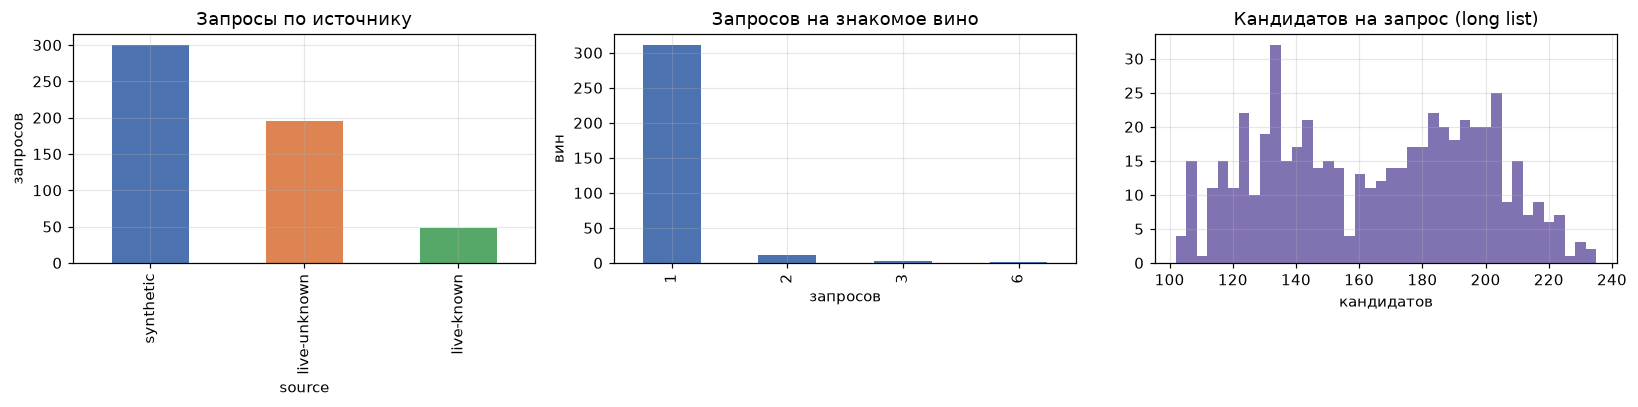

доля положительных пар: 0.0029 (один верный на ~207 кандидатов знакомого запроса)


,wines,queries,candidates_median,queries_per_wine
source,,,,
live-known,33,48,137.00,1.45
live-unknown,49,195,189.00,3.98
synthetic,300,300,151.00,1.00


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
Q.source.value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set(title='Запросы по источнику', ylabel='запросов')
per_wine = Q[Q.known].groupby('wine').size()
per_wine.value_counts().sort_index().plot.bar(ax=axes[1], color='#4C72B0')
axes[1].set(title='Запросов на знакомое вино', xlabel='запросов', ylabel='вин')
axes[2].hist(Q.n_candidates, bins=40, color='#8172B2')
axes[2].set(title='Кандидатов на запрос (long list)', xlabel='кандидатов')
plt.tight_layout(); plt.show()
print(f'доля положительных пар: {PAIRS.label.mean():.4f} '
      f'(один верный на ~{1/PAIRS[PAIRS.known].label.mean():.0f} кандидатов знакомого запроса)')
display(styled(Q.groupby('source').agg(wines=('wine', 'nunique'), queries=('query', 'size'),
                                       candidates_median=('n_candidates', 'median'))
               .assign(queries_per_wine=lambda t: t.queries / t.wines),
               bars=['wines', 'queries', 'queries_per_wine'], precision=2))


У живых незнакомых вин по нескольку кадров на вино, поэтому разбиение на фолды обязано
идти **по винам** (`GroupKFold`): иначе кадры одного вина окажутся и в обучении, и в
контроле, и CV будет мерить запоминание, а не обобщение.

Дисбаланс классов на уровне пар сильный (один верный на сотни кандидатов). Учим классификатор
с весами классов, но **метрики считаем на уровне запроса**: для продукта важно, какой
кандидат выиграл и насколько уверенно, а не AUC по всем парам.

### 2.2 Потолок retrieval

Решающий слой может выбрать только из того, что принесли ветки поиска. Если верного slug
нет в long list, ошибка — на стороне retrieval, и модель тут ни при чём.


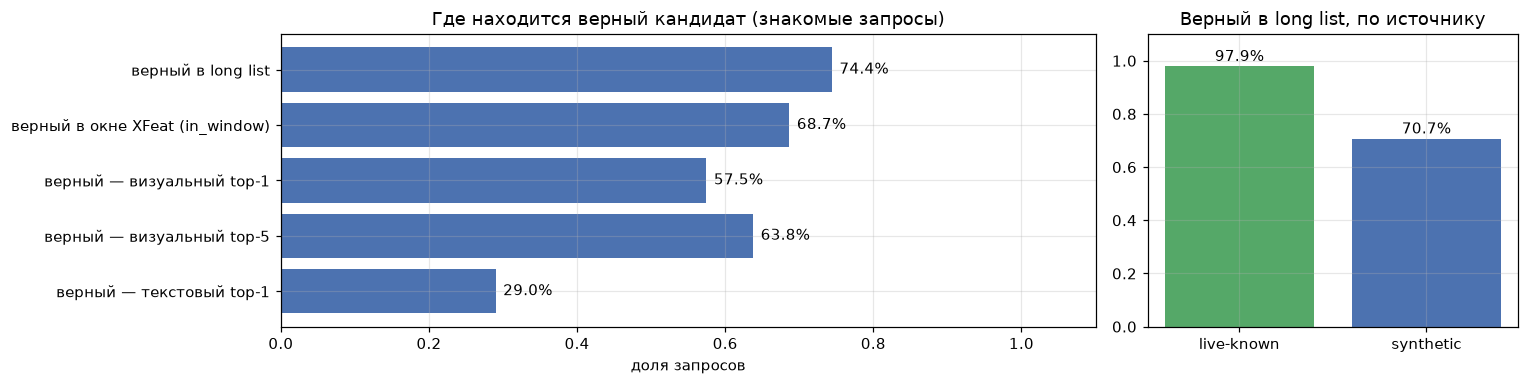

In [5]:
known_q = Q[Q.known]
pos = PAIRS[PAIRS.label == 1].set_index('query')

def share(mask):
    return mask.reindex(known_q['query'], fill_value=False).mean()

ceiling = pd.Series({
    'верный в long list': known_q.true_present.mean(),
    'верный в окне XFeat (in_window)': share(pos.in_window == 1),
    'верный — визуальный top-1': share(pos.vis_rank == 0),
    'верный — визуальный top-5': share(pos.vis_rank < 5),
    'верный — текстовый top-1': share(pos.txt_rank == 0),
}, name='доля знакомых запросов')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), gridspec_kw={'width_ratios': [2.2, 1]})
axes[0].barh(ceiling.index[::-1], ceiling.values[::-1], color='#4C72B0')
for y, v in enumerate(ceiling.values[::-1]):
    axes[0].text(v + .01, y, f'{v:.1%}', va='center')
axes[0].set(xlim=(0, 1.1), title='Где находится верный кандидат (знакомые запросы)',
            xlabel='доля запросов')
by_source = known_q.groupby('source').true_present.mean()
axes[1].bar(by_source.index, by_source.values, color=[PALETTE[s] for s in by_source.index])
for x, v in enumerate(by_source.values):
    axes[1].text(x, v + .02, f'{v:.1%}', ha='center')
axes[1].set(ylim=(0, 1.1), title='Верный в long list, по источнику')
plt.tight_layout(); plt.show()


### 2.3 Заглушки и пропуски

Пропусков в классическом смысле нет — вместо них заглушки: `vis_rank = 999` (кандидат пришёл
только из текста или по винодельне), `txt_rank = 999`, `txt_score = -1` (текст его не нашёл),
`in_window = 0` (геометрию не считали, нулевые инлаеры ничего не значат). Для деревьев это
нормально — заглушка отделяется одним сплитом, — но для линейной модели такие значения
искажают масштаб, это учитываем в бейзлайне.


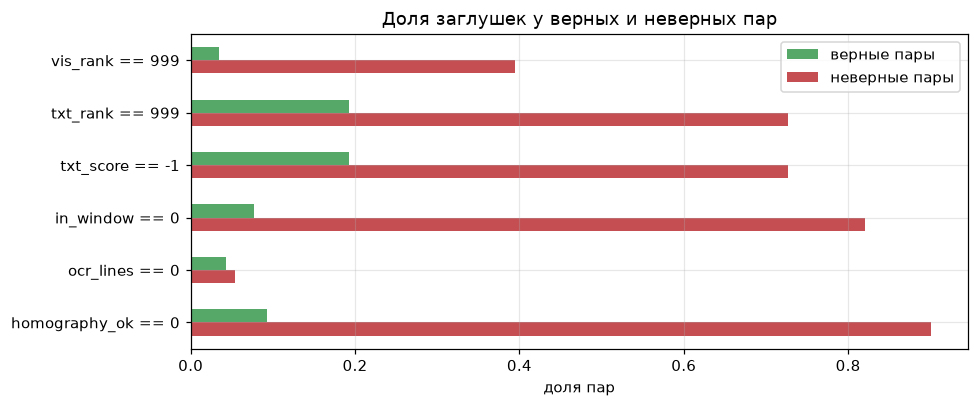

,верные пары,неверные пары
vis_rank == 999,0.035,0.394
txt_rank == 999,0.193,0.727
txt_score == -1,0.193,0.727
in_window == 0,0.077,0.821
ocr_lines == 0,0.042,0.054
homography_ok == 0,0.093,0.901


In [6]:
sentinels = {
    'vis_rank == 999': PAIRS.vis_rank >= 999,
    'txt_rank == 999': PAIRS.txt_rank >= 999,
    'txt_score == -1': PAIRS.txt_score <= -1,
    'in_window == 0': PAIRS.in_window == 0,
    'ocr_lines == 0': PAIRS.ocr_lines == 0,
    'homography_ok == 0': PAIRS.homography_ok == 0,
}
sentinel_table = pd.DataFrame({
    name: [mask[PAIRS.label == 1].mean(), mask[PAIRS.label == 0].mean()]
    for name, mask in sentinels.items()
}, index=['верные пары', 'неверные пары']).T
ax = sentinel_table.plot.barh(figsize=(9, 3.8), color=['#55A868', '#C44E52'])
ax.invert_yaxis(); ax.set(title='Доля заглушек у верных и неверных пар', xlabel='доля пар')
plt.tight_layout(); plt.show()
display(styled(sentinel_table, bars=list(sentinel_table.columns)))


### 2.4 Одномерная сила признаков

AUC каждого признака по отдельности на парах знакомых запросов. `AUC < 0.5` означает
обратную связь (например, ранг: меньше — лучше), поэтому сортируем по `|AUC − 0.5|`. Это не
важность в модели — признаки сильно коррелированы, — а первичная проверка, что сигнал
вообще есть и направлен туда, куда ожидаем.


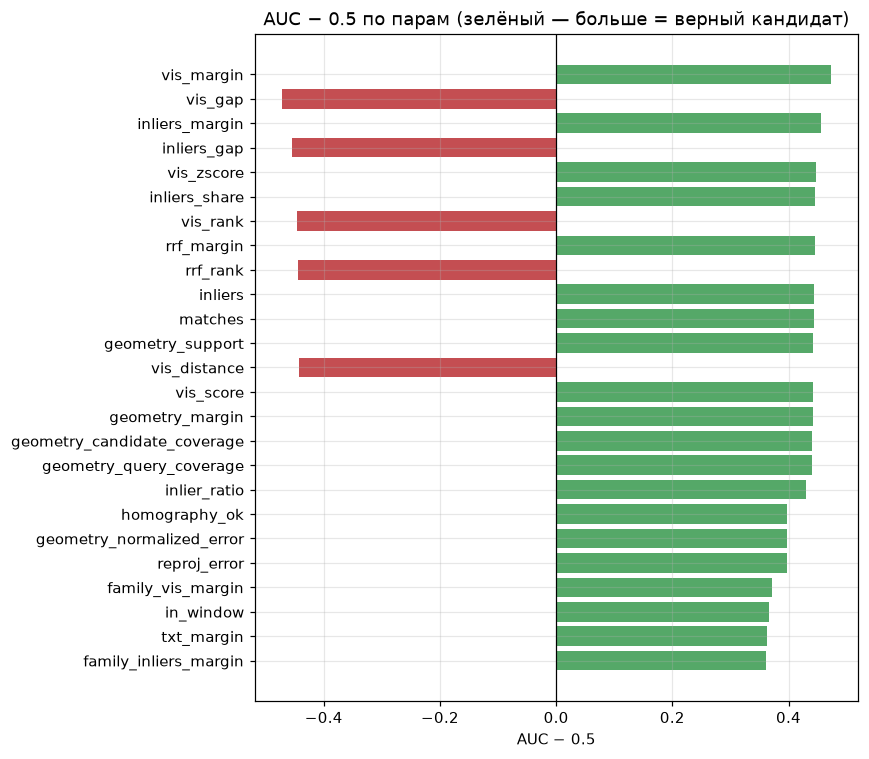

постоянные признаки: нет


In [7]:
known_pairs = PAIRS[PAIRS.known]
auc = pd.Series({f: roc_auc_score(known_pairs.label, known_pairs[f]) for f in FEATURE_NAMES
                 if known_pairs[f].nunique() > 1})
strength = (auc - .5).abs().sort_values(ascending=False)
top = strength.index[:25]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top[::-1], auc[top[::-1]] - .5,
        color=['#55A868' if v > 0 else '#C44E52' for v in auc[top[::-1]] - .5])
ax.axvline(0, color='k', lw=.8)
ax.set(title='AUC − 0.5 по парам (зелёный — больше = верный кандидат)', xlabel='AUC − 0.5')
plt.tight_layout(); plt.show()
constant = [f for f in FEATURE_NAMES if known_pairs[f].nunique() <= 1]
print('постоянные признаки:', constant or 'нет')


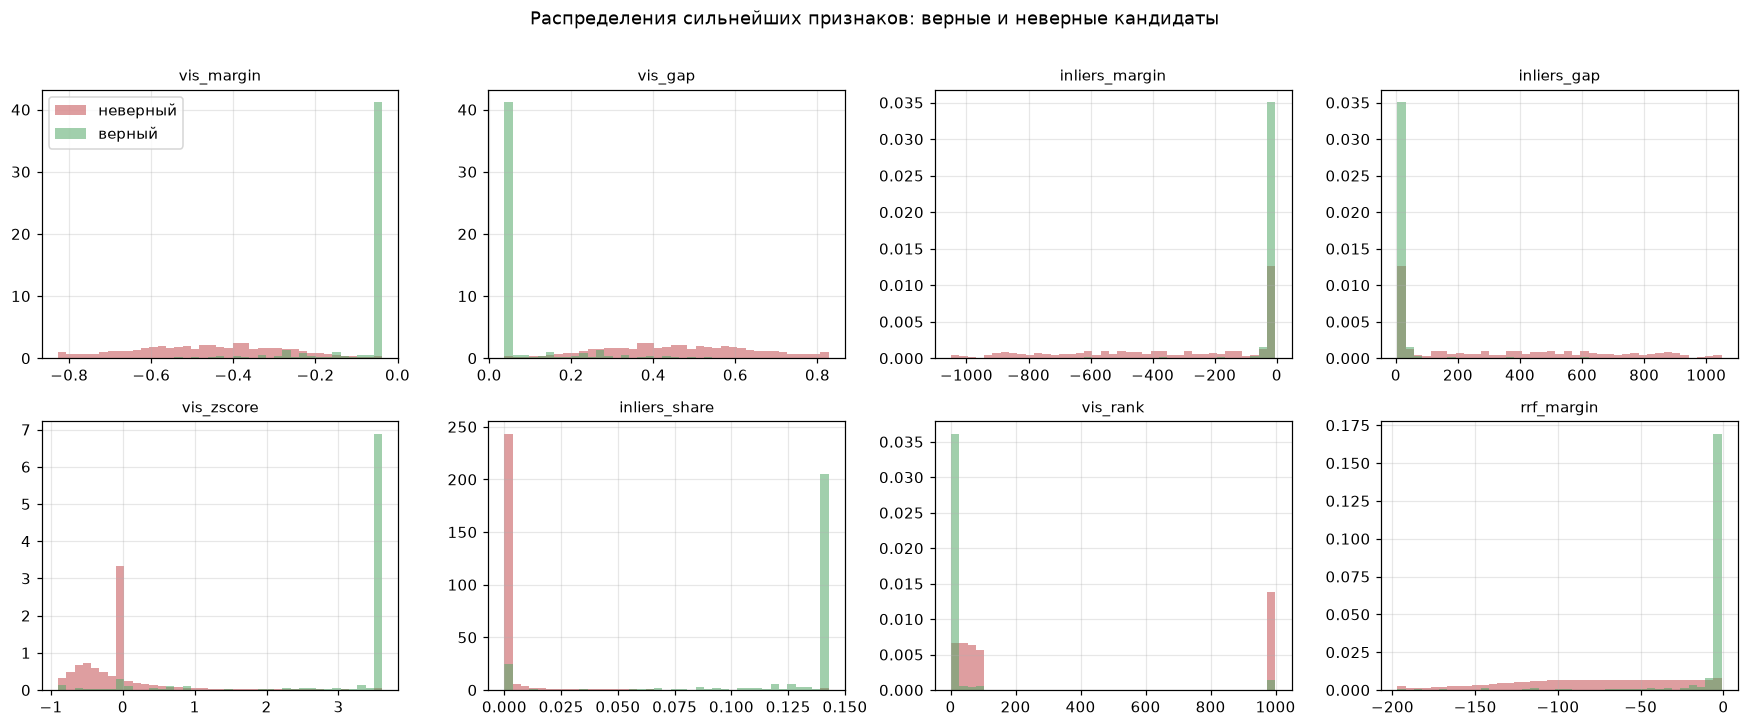

In [8]:
top8 = list(strength.index[:8])
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for ax, feature in zip(axes.ravel(), top8):
    values = known_pairs[feature]
    lo, hi = np.nanpercentile(values, [1, 99])
    bins = np.linspace(lo, hi if hi > lo else lo + 1, 40)
    for label, color in ((0, '#C44E52'), (1, '#55A868')):
        ax.hist(values[known_pairs.label == label].clip(lo, hi), bins=bins, density=True,
                alpha=.55, color=color, label='верный' if label else 'неверный')
    ax.set_title(feature, fontsize=10)
axes[0, 0].legend()
plt.suptitle('Распределения сильнейших признаков: верные и неверные кандидаты', y=1.01)
plt.tight_layout(); plt.show()


### 2.5 Избыточность

Ранговая корреляция Спирмена между признаками. Сильно коррелированные пары (`|ρ| > 0.95`) не
вредят бустингу по качеству, но размазывают важность между дублями — это нужно помнить при
чтении SHAP в разделе 5.


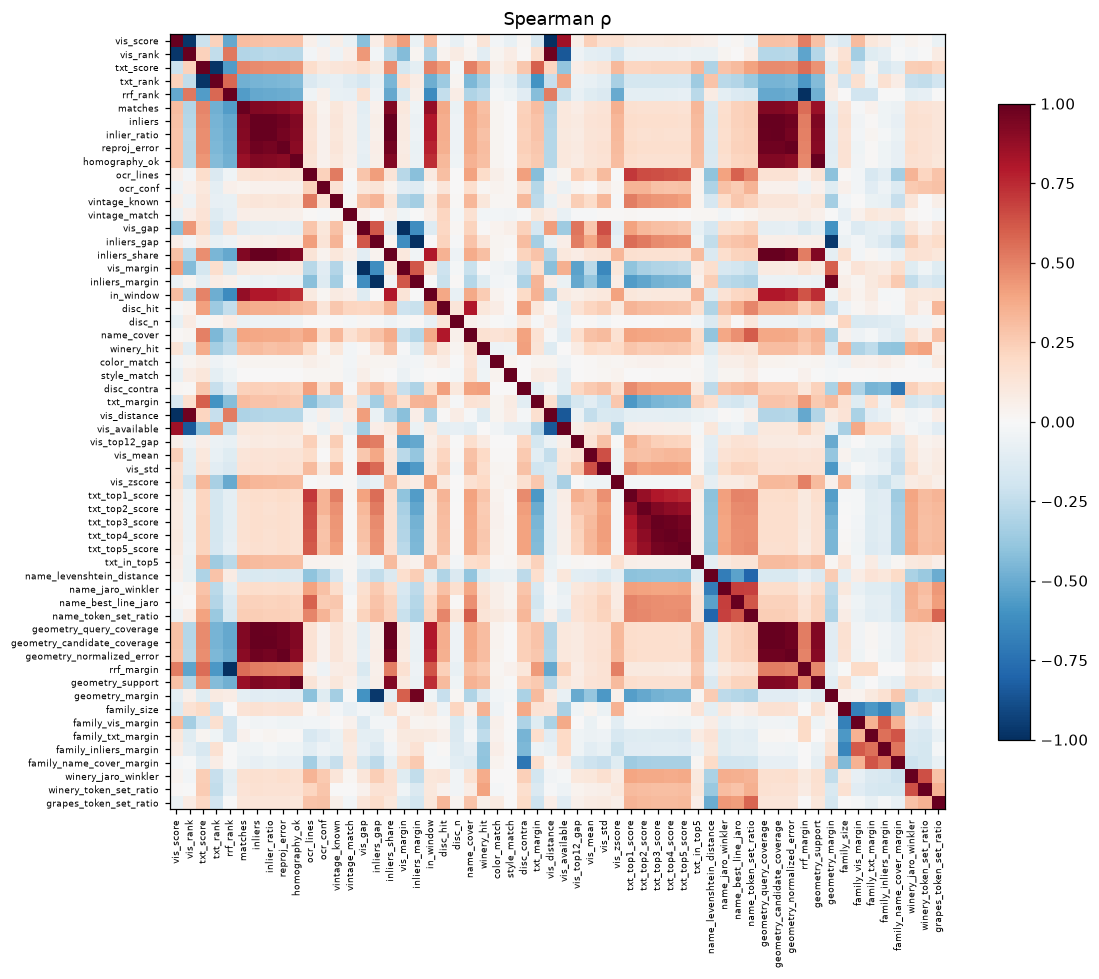

пар с |ρ| > 0.95: 34; показаны первые 20


,признак A,признак B,ρ,|ρ|
0,vis_score,vis_distance,-1.000,1.000
1,rrf_rank,rrf_margin,-1.000,1.000
2,reproj_error,geometry_normalized_error,1.000,1.000
3,vis_gap,vis_margin,-1.000,1.000
4,inliers_gap,inliers_margin,-1.000,1.000
5,geometry_query_coverage,geometry_candidate_coverage,0.999,0.999
6,inliers,geometry_candidate_coverage,0.998,0.998
7,inliers,geometry_query_coverage,0.998,0.998
8,homography_ok,geometry_support,0.997,0.997
9,inliers,inliers_share,0.997,0.997


In [9]:
sample = known_pairs.sample(min(20000, len(known_pairs)), random_state=SEED)
varying = [f for f in FEATURE_NAMES if f not in constant]
rho = sample[varying].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(rho, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(varying)), varying, rotation=90, fontsize=6)
ax.set_yticks(range(len(varying)), varying, fontsize=6)
plt.colorbar(im, fraction=.03); ax.set_title('Spearman ρ'); ax.grid(False)
plt.tight_layout(); plt.show()
upper = rho.where(np.triu(np.ones(rho.shape, bool), 1)).stack()
redundant = (upper[upper.abs() > .95].sort_values(key=abs, ascending=False)
             .rename('ρ').to_frame().reset_index()
             .rename(columns={'level_0': 'признак A', 'level_1': 'признак B'}))
print(f'пар с |ρ| > 0.95: {len(redundant)}; показаны первые 20')
display(styled(redundant.head(20).assign(**{'|ρ|': lambda t: t['ρ'].abs()}), good=['|ρ|']))


### 2.6 Сдвиг между синтетикой и живыми кадрами

Сравниваем признаки уровня запроса (одинаковые у всех кандидатов одного запроса) и признаки
лучшего визуального кандидата у трёх источников. Две разницы читаются по-разному:

* **synthetic − live-known** — оба знакомые, различается только способ съёмки. Это чистый
  **сдвиг домена**: чем он больше, тем сильнее признак выдаёт «синтетику», а не «знакомое»;
* **live-known − live-unknown** — оба живые, различается только наличие вина в каталоге. Это
  **полезный сигнал** отказа, который модель и должна выучить.


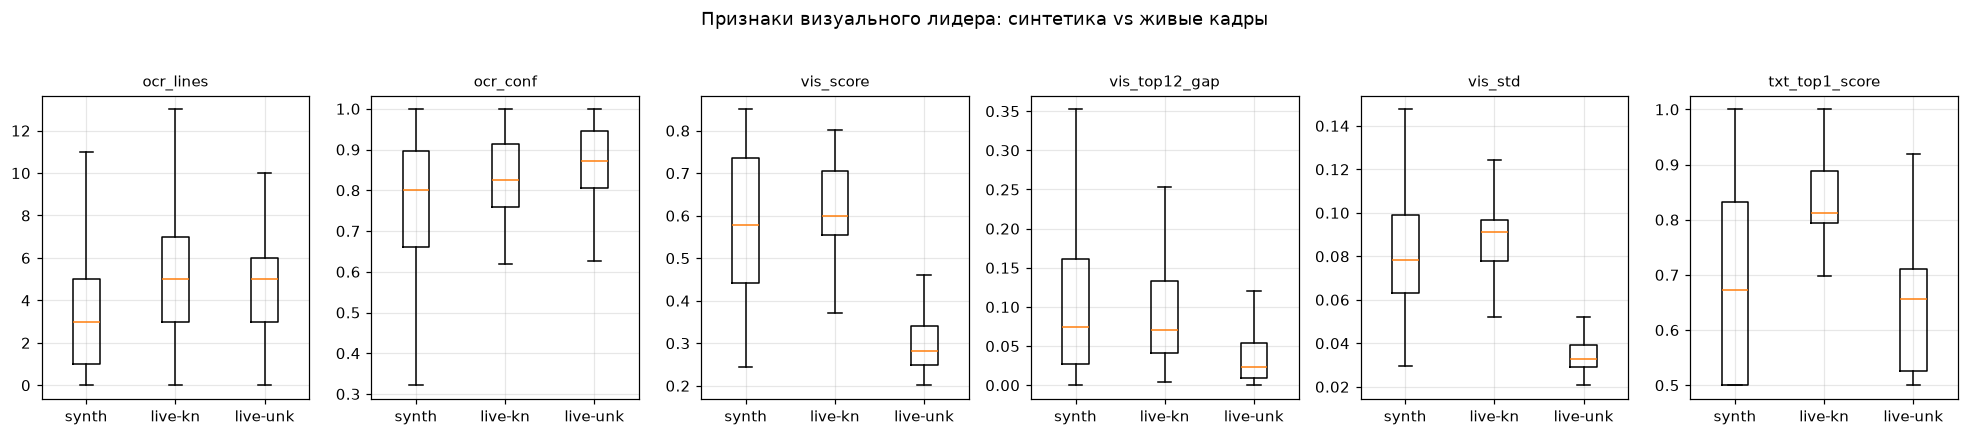

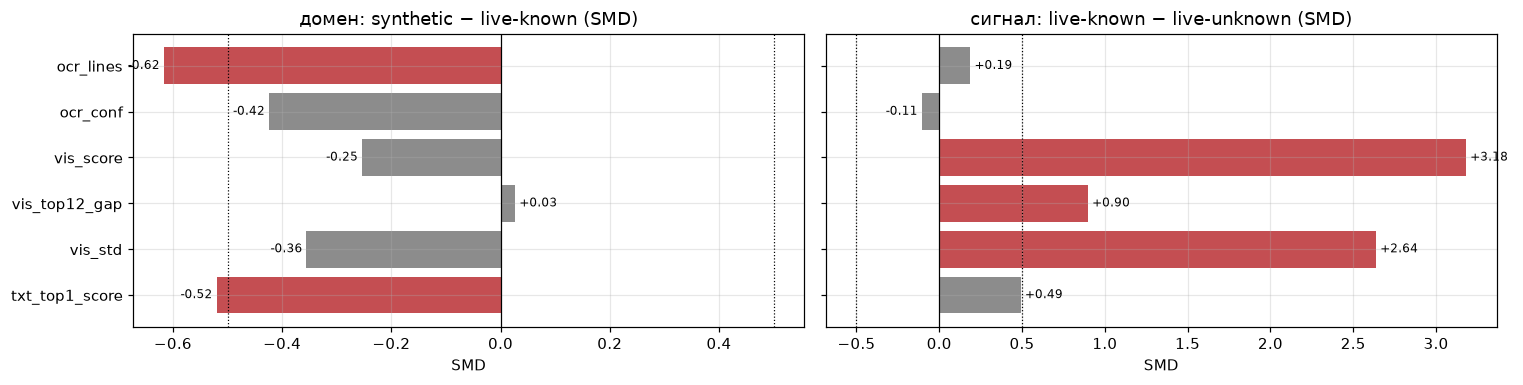

,домен: synthetic − live-known,сигнал: live-known − live-unknown
ocr_lines,-0.62,0.19
ocr_conf,-0.42,-0.11
vis_score,-0.25,3.18
vis_top12_gap,0.03,0.90
vis_std,-0.36,2.64
txt_top1_score,-0.52,0.49


In [10]:
leaders = PAIRS[PAIRS.vis_rank == 0].set_index('query')
query_level = ['ocr_lines', 'ocr_conf', 'vis_score', 'vis_top12_gap', 'vis_std', 'txt_top1_score']
fig, axes = plt.subplots(1, len(query_level), figsize=(18, 3.8))
for ax, feature in zip(axes, query_level):
    sources = ('synthetic', 'live-known', 'live-unknown')
    data = [leaders.loc[leaders.source == s, feature] for s in sources]
    ax.boxplot(data, tick_labels=['synth', 'live-kn', 'live-unk'], showfliers=False)
    ax.set_title(feature, fontsize=10)
plt.suptitle('Признаки визуального лидера: синтетика vs живые кадры', y=1.03)
plt.tight_layout(); plt.show()

def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2 + 1e-12)
by_source = {s: leaders[leaders.source == s] for s in ('synthetic', 'live-known', 'live-unknown')}
shift = pd.DataFrame({
    'домен: synthetic − live-known': {f: smd(by_source['synthetic'][f], by_source['live-known'][f])
                                      for f in query_level},
    'сигнал: live-known − live-unknown': {f: smd(by_source['live-known'][f],
                                                 by_source['live-unknown'][f])
                                          for f in query_level},
})
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), sharey=True)
for ax, (title, column) in zip(axes, shift.items()):
    ax.barh(column.index[::-1], column.values[::-1],
            color=['#C44E52' if abs(v) > .5 else '#8c8c8c' for v in column.values[::-1]])
    for y, v in enumerate(column.values[::-1]):
        ax.text(v, y, f' {v:+.2f} ', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    for x in (-.5, .5): ax.axvline(x, color='k', ls=':', lw=.8)
    ax.axvline(0, color='k', lw=.8); ax.set(title=f'{title} (SMD)', xlabel='SMD')
plt.tight_layout(); plt.show()
display(styled(shift, precision=2))


Как читать: признак опасен, если у него большой **доменный** сдвиг и маленький
**сигнальный** — он отличает синтетику от живого кадра, а не знакомое вино от незнакомого.
Такие признаки (`vis_std`, `vis_mean`, `ocr_lines`) ниже проверяем отдельным набором `v3-nodomain`,
где их нет.

### 2.7 Эвристические бейзлайны

Что даёт выбор кандидата одним признаком, без обучения. Любая модель ниже должна их обыграть.


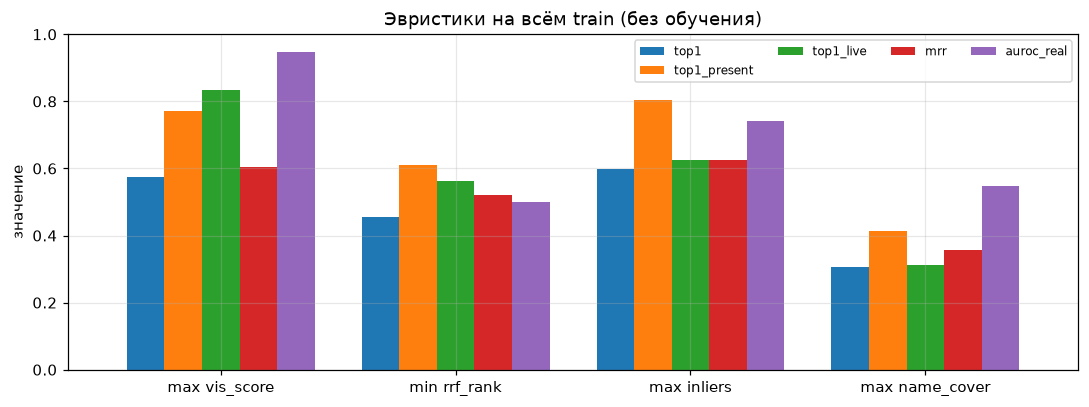

,top1,top1_present,top1_live,mrr,auroc_real
max vis_score,0.575,0.772,0.833,0.606,0.946
min rrf_rank,0.454,0.610,0.562,0.520,0.500
max inliers,0.598,0.803,0.625,0.624,0.740
max name_cover,0.307,0.413,0.312,0.357,0.546


In [11]:
COL = {name: i for i, name in enumerate(FEATURE_NAMES)}

def query_metrics(score_of, qs):
    """Метрики уровня запроса. score_of(q) -> оценки кандидатов запроса q."""
    top_score, correct, rr, known = [], [], [], []
    for q in qs:
        scores, labels = score_of(q), LABELS[q]
        best = int(np.argmax(scores))
        top_score.append(scores[best]); correct.append(bool(labels[best]))
        if labels.any():
            true_score = scores[labels == 1].max()
            rr.append(1.0 / (1 + int((scores > true_score).sum())))
        else:
            rr.append(0.0)
        known.append(not by_query[q][0].true_id.startswith(TD.UNKNOWN_PREFIX))
    top_score, correct, rr, known = map(np.asarray, (top_score, correct, rr, known))
    present = np.asarray([LABELS[q].any() for q in qs], bool)
    live = np.asarray([GROUP[q].startswith('live-') for q in qs], bool)
    auroc = (roc_auc_score(np.r_[np.ones(known.sum()), np.zeros((~known).sum())],
                           np.r_[top_score[known], top_score[~known]])
             if known.any() and (~known).any() else np.nan)
    return {'top1': correct[known].mean(), 'top1_present': correct[known & present].mean(),
            'top1_live': correct[known & live].mean() if (known & live).any() else np.nan,
            'mrr': rr[known].mean(), 'auroc_real': auroc,
            'top_score': top_score, 'correct': correct, 'rr': rr, 'known': known}

heuristics = {
    'max vis_score': lambda q: FULL[q][:, COL['vis_score']],
    'min rrf_rank': lambda q: -FULL[q][:, COL['rrf_rank']],
    'max inliers': lambda q: FULL[q][:, COL['inliers']] + 1e-3 * FULL[q][:, COL['vis_score']],
    'max name_cover': lambda q: FULL[q][:, COL['name_cover']] + 1e-3 * FULL[q][:, COL['vis_score']],
}
METRICS = ('top1', 'top1_present', 'top1_live', 'mrr', 'auroc_real')
baseline_table = pd.DataFrame({name: {k: v for k, v in query_metrics(f, queries).items()
                                      if k in METRICS}
                               for name, f in heuristics.items()}).T
ax = baseline_table.plot.bar(figsize=(10, 3.8), rot=0, width=.8)
ax.set(ylim=(0, 1), title='Эвристики на всём train (без обучения)', ylabel='значение')
ax.legend(ncol=4, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()
display(styled(baseline_table, good=list(baseline_table.columns)))


## 3. Схема валидации

* **Внешняя CV** — `GroupKFold(5)` по винам (незнакомые вина — тоже группы). Даёт честную
  оценку всей процедуры, включая подбор гиперпараметров.
* **Внутренняя CV** — `GroupKFold(3)` по винам внутри внешнего train. На ней Optuna (TPE,
  15 испытаний) выбирает гиперпараметры; внешний test-фолд подбор не видит.
* **Целевая метрика подбора** — `0.5·MRR + 0.5·AUROC_real`:
  * MRR верного кандидата среди знакомых запросов — насколько высоко модель ставит верный
    slug. Гладче top-1: при ~80 знакомых запросах во внутреннем фолде top-1 меняется
    ступеньками по 1.3 п.п. и почти не различает испытания;
  * AUROC_real — отделяет ли уверенность лидера знакомые запросы от живых незнакомых. Это
    главный долг системы (ложные приёмы), и оптимизировать одну точность нельзя.
* **Отчётные метрики** — top-1 знакомых, top-1 при условии, что верный кандидат есть в
  long list (это качество самого решающего слоя, без промахов retrieval), top-1 на **живых**
  знакомых (`top1_live`, ближе всего к тесту), MRR, AUROC_real; разброс по фолдам и
  bootstrap-интервалы по винам.


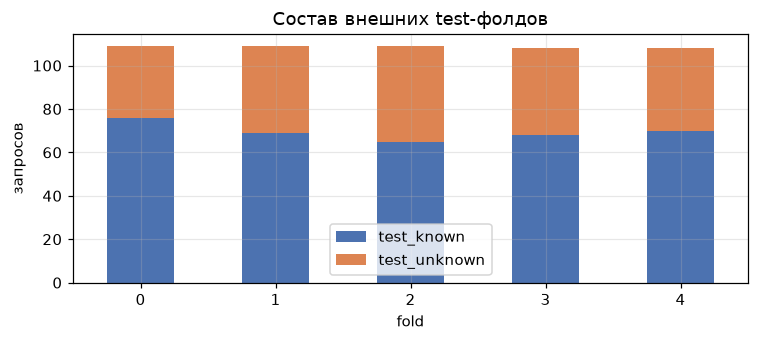

,train_q,test_q,test_known,test_unknown,wine_overlap
fold,,,,,
0,434,109,76,33,0
1,434,109,69,40,0
2,434,109,65,44,0
3,435,108,68,40,0
4,435,108,70,38,0


In [12]:
wines_of = Q.set_index('query').wine
outer = list(GroupKFold(OUTER_FOLDS).split(queries, groups=wines_of[queries]))
folds_table = pd.DataFrame([{
    'fold': i, 'train_q': len(tr), 'test_q': len(te),
    'test_known': int(Q.known.iloc[te].sum()), 'test_unknown': int((~Q.known.iloc[te]).sum()),
    'wine_overlap': len(set(wines_of.iloc[tr]) & set(wines_of.iloc[te])),
} for i, (tr, te) in enumerate(outer)]).set_index('fold')
ax = folds_table[['test_known', 'test_unknown']].plot.bar(
    stacked=True, figsize=(7, 3.2), rot=0, color=[PALETTE['synthetic'], PALETTE['live-unknown']])
ax.set(title='Состав внешних test-фолдов', ylabel='запросов')
plt.tight_layout(); plt.show()
display(styled(folds_table, bars=['test_known', 'test_unknown'], bad=['wine_overlap']))


## 4. Модели и сравнение

Кандидаты:

* эвристики из 2.7 (без обучения);
* логистическая регрессия на стандартизованных признаках (`class_weight='balanced'`);
* CatBoost с текущими боевыми параметрами (`iterations=400, depth=6, lr=0.05, l2=5`) на
  трёх наборах признаков: **v3** (префикс, на котором обучен действующий decider), **v4**
  (добавлены отступы от конкурентов, OCR к винодельне и сортам) и **v3-nodomain** (v3 без
  признаков домена съёмки `vis_std`, `vis_mean`, `ocr_lines`, см. 2.6);
* CatBoost после вложенного подбора Optuna на лучшем наборе признаков.

Все обучаются тем же способом, что боевой скрипт: каждый знакомый запрос дополнительно
подаётся без верного кандидата (учит отказу), живые кадры весят в 3 раза больше.


бейзлайны: 93 s


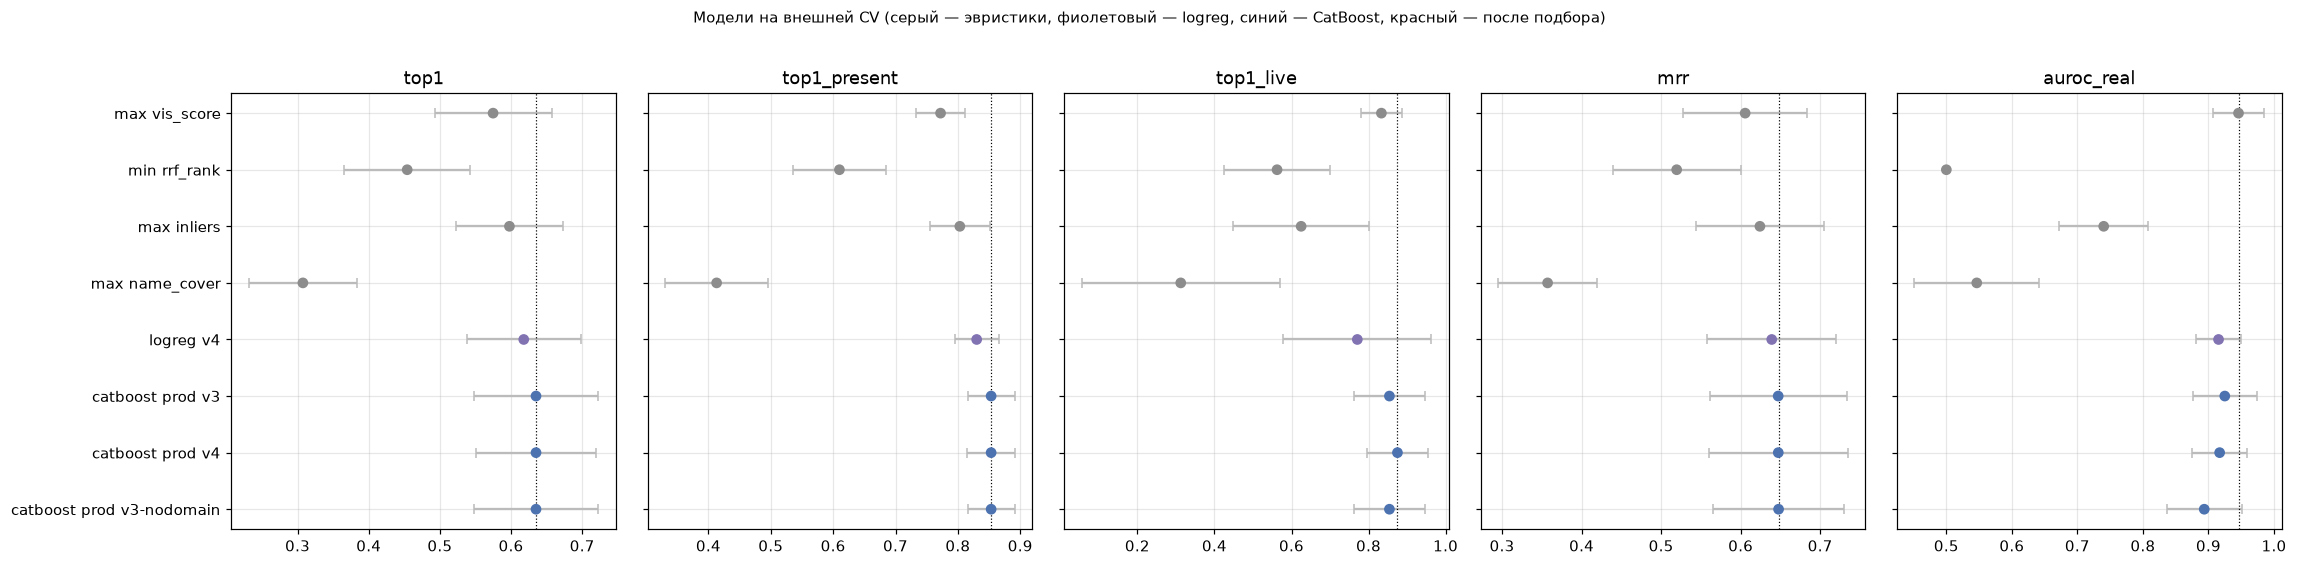

,top1 (OOF),top1_present (OOF),top1_live (OOF),mrr (OOF),auroc_real (OOF),top1 ± fold sd,auroc_real ± fold sd
max vis_score,0.575,0.772,0.833,0.606,0.946,0.082,0.039
min rrf_rank,0.454,0.610,0.562,0.520,0.500,0.088,0.000
max inliers,0.598,0.803,0.625,0.624,0.740,0.075,0.068
max name_cover,0.307,0.413,0.312,0.357,0.546,0.076,0.095
logreg v4,0.618,0.830,0.771,0.639,0.915,0.080,0.035
catboost prod v3,0.635,0.853,0.854,0.647,0.925,0.088,0.048
catboost prod v4,0.635,0.853,0.875,0.647,0.917,0.084,0.042
catboost prod v3-nodomain,0.635,0.853,0.854,0.648,0.894,0.088,0.057


In [13]:
V3 = list(range(FEATURE_NAMES.index('geometry_normalized_error') + 1))
DOMAIN = ('vis_std', 'vis_mean', 'ocr_lines')
V3_NODOMAIN = [i for i in V3 if FEATURE_NAMES[i] not in DOMAIN]
FEATURE_SETS = {'v3': V3, 'v4': ALL, 'v3-nodomain': V3_NODOMAIN}
BASE = dict(loss_function='Logloss', random_seed=SEED, thread_count=-1,
            allow_writing_files=False, verbose=False)
PRODUCTION = dict(iterations=400, learning_rate=0.05, depth=6, l2_leaf_reg=5,
                  auto_class_weights='Balanced')

def fit_catboost(params, qs, cols):
    X, y, w = training_matrix(qs, cols)
    return CatBoostClassifier(**BASE, **params).fit(X, y, sample_weight=w)

def fit_logreg(qs, cols):
    X, y, w = training_matrix(qs, cols)
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(C=0.1, class_weight='balanced', max_iter=3000))
    return model.fit(X, y, logisticregression__sample_weight=w)

def model_scorer(model, cols):
    return lambda q: model.predict_proba(FULL[q][:, cols])[:, 1]

def outer_cv(fit):
    """OOF-метрики: fit(train_queries) -> scorer(q)."""
    per_fold, oof = [], {}
    for i, (tr, te) in enumerate(outer):
        scorer = fit([queries[j] for j in tr])
        test_q = [queries[j] for j in te]
        m = query_metrics(scorer, test_q)
        per_fold.append({k: m[k] for k in METRICS})
        for j, q in enumerate(test_q):
            oof[q] = (m['top_score'][j], m['correct'][j], m['rr'][j])
    return pd.DataFrame(per_fold), oof

def pooled_metrics(oof):
    top = np.array([oof[q][0] for q in queries]); correct = np.array([oof[q][1] for q in queries])
    rr = np.array([oof[q][2] for q in queries]); known = Q.known.to_numpy()
    present = Q.true_present.to_numpy(); live = Q.group.str.startswith('live-').to_numpy()
    return {'top1': correct[known].mean(), 'top1_present': correct[known & present].mean(),
            'top1_live': correct[known & live].mean(),
            'mrr': rr[known].mean(),
            'auroc_real': roc_auc_score(np.r_[np.ones(known.sum()), np.zeros((~known).sum())],
                                        np.r_[top[known], top[~known]])}

RESULTS, OOF = {}, {}
for name, f in heuristics.items():
    RESULTS[name], OOF[name] = outer_cv(lambda qs, f=f: f)
started = time.time()
RESULTS['logreg v4'], OOF['logreg v4'] = outer_cv(lambda qs: model_scorer(fit_logreg(qs, ALL), ALL))
for fs, cols in FEATURE_SETS.items():
    RESULTS[f'catboost prod {fs}'], OOF[f'catboost prod {fs}'] = outer_cv(
        lambda qs, cols=cols: model_scorer(fit_catboost(PRODUCTION, qs, cols), cols))
print(f'бейзлайны: {time.time() - started:.0f} s')

def summary(names):
    rows = {}
    for name in names:
        folds, pooled = RESULTS[name], pooled_metrics(OOF[name])
        rows[name] = {**{f'{k} (OOF)': v for k, v in pooled.items()},
                      **{f'{k} ± fold sd': folds[k].std() for k in ('top1', 'auroc_real')}}
    return pd.DataFrame(rows).T


def plot_comparison(names):
    """Точка — OOF по всем внешним фолдам, отрезок — ± стандартное отклонение по фолдам."""
    names = list(names)
    fig, axes = plt.subplots(1, len(METRICS), figsize=(4.2 * len(METRICS), .45 * len(names) + 1.4),
                             sharey=True)
    for ax, metric in zip(axes, METRICS):
        values = [pooled_metrics(OOF[n])[metric] for n in names]
        errors = [RESULTS[n][metric].std() for n in names]
        colors = ['#C44E52' if 'tuned' in n else '#4C72B0' if 'catboost' in n
                  else '#8172B2' if 'logreg' in n else '#8c8c8c' for n in names]
        ax.errorbar(values, range(len(names)), xerr=errors, fmt='none', ecolor='#bbbbbb',
                    capsize=3)
        ax.scatter(values, range(len(names)), c=colors, zorder=3)
        best = int(np.nanargmax(values)); ax.axvline(values[best], color='k', ls=':', lw=.8)
        ax.set_title(metric)
    axes[0].set_yticks(range(len(names)), names); axes[0].invert_yaxis()
    plt.suptitle('Модели на внешней CV (серый — эвристики, фиолетовый — logreg, '
                 'синий — CatBoost, красный — после подбора)', y=1.02, fontsize=10)
    plt.tight_layout(); plt.show()
    table = summary(names)
    display(styled(table, good=[c for c in table.columns if 'OOF' in c],
                   bad=[c for c in table.columns if 'sd' in c]))

plot_comparison(RESULTS)


### 4.1 Вложенный подбор гиперпараметров

Пространство поиска — параметры, которые у CatBoost реально управляют сложностью и
регуляризацией: глубина, темп обучения и число деревьев, L2 на листья, случайность сплитов
и бэггинг, а также схема весов классов (от неё зависит «сырая» шкала уверенности, которую
потом калибруем). Внутренние фолды отчитываются Optuna по одному, и заведомо плохие
испытания обрываются `MedianPruner`.


In [14]:
def objective_value(name):
    m = pooled_metrics(OOF[name])
    return 0.5 * m['mrr'] + 0.5 * m['auroc_real']

best_fs = max(FEATURE_SETS, key=lambda fs: objective_value(f'catboost prod {fs}'))
COLS = FEATURE_SETS[best_fs]
print('набор признаков для подбора:', best_fs, f'({len(COLS)} признаков)')

def suggest(trial):
    return dict(
        depth=trial.suggest_int('depth', 4, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        iterations=trial.suggest_int('iterations', 200, 800, step=100),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        random_strength=trial.suggest_float('random_strength', 0.1, 5.0, log=True),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 2.0),
        auto_class_weights=trial.suggest_categorical('auto_class_weights',
                                                     ['Balanced', 'SqrtBalanced']),
    )

def objective_on(train_q, cols):
    wines = wines_of[train_q].to_numpy()
    inner = list(GroupKFold(INNER_FOLDS).split(train_q, groups=wines))
    def objective(trial):
        params, values = suggest(trial), []
        for step, (tr, va) in enumerate(inner):
            model = fit_catboost(params, [train_q[j] for j in tr], cols)
            m = query_metrics(model_scorer(model, cols), [train_q[j] for j in va])
            values.append(0.5 * m['mrr'] + 0.5 * m['auroc_real'])
            trial.report(float(np.mean(values)), step)
            if trial.should_prune(): raise optuna.TrialPruned()
        return float(np.mean(values))
    return objective

def tune(train_q, cols, n_trials, seed):
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=seed),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
    study.enqueue_trial({**{k: v for k, v in PRODUCTION.items()},
                         'random_strength': 1.0, 'bagging_temperature': 1.0})
    study.optimize(objective_on(train_q, cols), n_trials=n_trials)
    return study

started, nested_params, per_fold, nested_oof = time.time(), [], [], {}
for i, (tr, te) in enumerate(outer):
    train_q, test_q = [queries[j] for j in tr], [queries[j] for j in te]
    study = tune(train_q, COLS, TRIALS_NESTED, SEED + i)
    model = fit_catboost(study.best_params, train_q, COLS)
    m = query_metrics(model_scorer(model, COLS), test_q)
    per_fold.append({k: m[k] for k in METRICS})
    for j, q in enumerate(test_q): nested_oof[q] = (m['top_score'][j], m['correct'][j], m['rr'][j])
    nested_params.append({'fold': i, 'inner_score': study.best_value, **study.best_params})
    print(f'fold {i}: inner {study.best_value:.3f} -> outer top1 {m["top1"]:.3f} '
          f'auroc {m["auroc_real"]:.3f}  ({time.time() - started:.0f} s)')
RESULTS['catboost nested-tuned'], OOF['catboost nested-tuned'] = pd.DataFrame(per_fold), nested_oof
nested_table = pd.DataFrame(nested_params).set_index('fold')
display(styled(nested_table, good=['inner_score'],
               bars=['depth', 'learning_rate', 'iterations', 'l2_leaf_reg', 'random_strength',
                     'bagging_temperature']))


набор признаков для подбора: v3 (47 признаков)


fold 0: inner 0.774 -> outer top1 0.776 auroc 0.984  (202 s)


fold 1: inner 0.805 -> outer top1 0.565 auroc 0.933  (527 s)


fold 2: inner 0.792 -> outer top1 0.631 auroc 0.945  (707 s)


fold 3: inner 0.800 -> outer top1 0.662 auroc 0.855  (902 s)


fold 4: inner 0.803 -> outer top1 0.529 auroc 0.955  (1162 s)


,inner_score,depth,learning_rate,iterations,l2_leaf_reg,random_strength,bagging_temperature,auto_class_weights
fold,,,,,,,,
0,0.774,6,0.059,300,5.629,0.946,0.980,SqrtBalanced
1,0.805,7,0.023,500,4.239,0.199,1.986,SqrtBalanced
2,0.792,4,0.060,700,2.534,0.457,0.642,SqrtBalanced
3,0.800,5,0.037,800,16.905,0.584,1.160,Balanced
4,0.803,6,0.057,300,8.147,0.878,0.350,Balanced


Таблица выше — **стабильность подбора**: если лучшие параметры сильно скачут между
внешними фолдами при близком inner-score, поверхность плоская, и выигрыш от подбора
ожидаемо мал.

### 4.2 Итоговое сравнение и значимость разницы

Разница между моделями на ~300 знакомых запросах легко оказывается шумом. Bootstrap по
**винам** (а не по запросам — снимки одного вина зависимы) даёт 95%-интервал для разницы
«подобранный − текущий» по top-1 и AUROC_real.


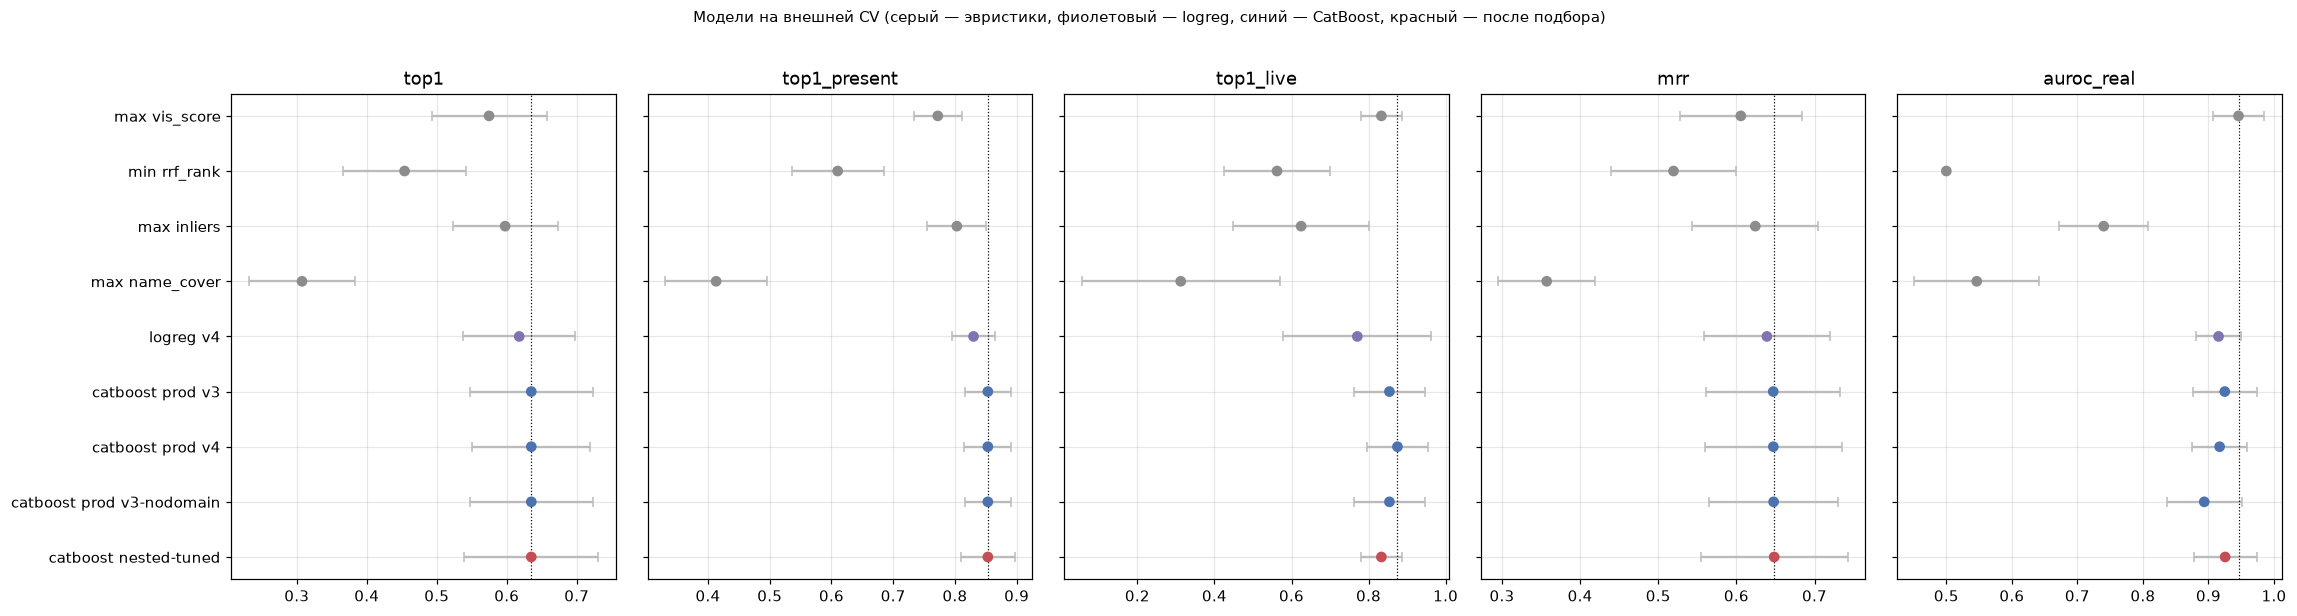

,top1 (OOF),top1_present (OOF),top1_live (OOF),mrr (OOF),auroc_real (OOF),top1 ± fold sd,auroc_real ± fold sd
max vis_score,0.575,0.772,0.833,0.606,0.946,0.082,0.039
min rrf_rank,0.454,0.610,0.562,0.520,0.500,0.088,0.000
max inliers,0.598,0.803,0.625,0.624,0.740,0.075,0.068
max name_cover,0.307,0.413,0.312,0.357,0.546,0.076,0.095
logreg v4,0.618,0.830,0.771,0.639,0.915,0.080,0.035
catboost prod v3,0.635,0.853,0.854,0.647,0.925,0.088,0.048
catboost prod v4,0.635,0.853,0.875,0.647,0.917,0.084,0.042
catboost prod v3-nodomain,0.635,0.853,0.854,0.648,0.894,0.088,0.057
catboost nested-tuned,0.635,0.853,0.833,0.648,0.925,0.096,0.048


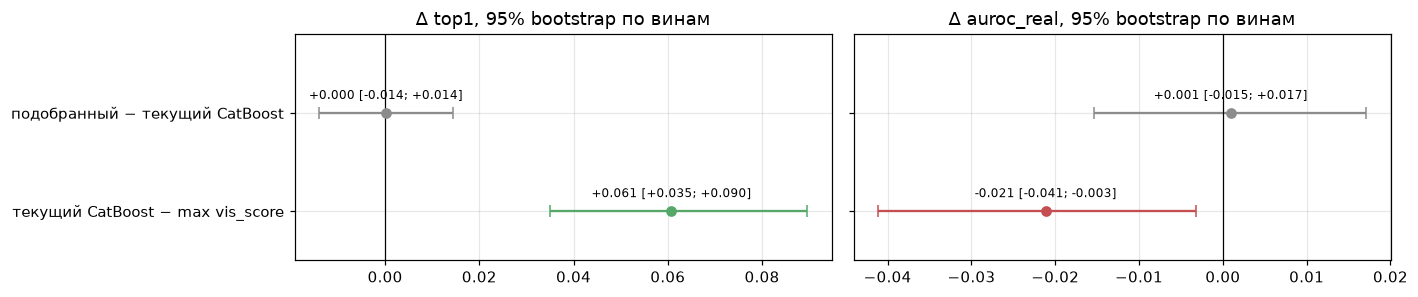

зелёный — разница значима в пользу первой модели, серый — интервал накрывает ноль


In [15]:
plot_comparison(RESULTS)

def bootstrap_diff(a, b, n=2000):
    rng = np.random.default_rng(SEED)
    wines = Q.wine.to_numpy(); unique = np.unique(wines)
    index = {w: np.flatnonzero(wines == w) for w in unique}
    top = {k: np.array([OOF[k][q][0] for q in queries]) for k in (a, b)}
    cor = {k: np.array([OOF[k][q][1] for q in queries]) for k in (a, b)}
    known = Q.known.to_numpy(); diffs = []
    for _ in range(n):
        rows = np.concatenate([index[w] for w in rng.choice(unique, len(unique))])
        kn = known[rows]
        if kn.all() or not kn.any(): continue
        d = []
        for k in (a, b):
            t = top[k][rows]
            d.append((cor[k][rows][kn].mean(),
                      roc_auc_score(np.r_[np.ones(kn.sum()), np.zeros((~kn).sum())],
                                    np.r_[t[kn], t[~kn]])))
        diffs.append(np.subtract(d[0], d[1]))
    diffs = np.asarray(diffs)
    return pd.DataFrame({'mean': diffs.mean(0), 'ci_low': np.percentile(diffs, 2.5, 0),
                         'ci_high': np.percentile(diffs, 97.5, 0)}, index=['top1', 'auroc_real'])

comparisons = {
    'подобранный − текущий CatBoost': bootstrap_diff('catboost nested-tuned',
                                                     f'catboost prod {best_fs}'),
    'текущий CatBoost − max vis_score': bootstrap_diff(f'catboost prod {best_fs}',
                                                       'max vis_score'),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 2.8), sharey=True)
for ax, metric in zip(axes, ('top1', 'auroc_real')):
    for y, (label, frame) in enumerate(comparisons.items()):
        row = frame.loc[metric]
        significant = row.ci_low > 0 or row.ci_high < 0
        color = '#55A868' if significant and row['mean'] > 0 else (
            '#C44E52' if significant else '#8c8c8c')
        ax.errorbar(row['mean'], y, fmt='o', color=color, capsize=4,
                    xerr=[[row['mean'] - row.ci_low], [row.ci_high - row['mean']]])
        ax.annotate(f"{row['mean']:+.3f} [{row.ci_low:+.3f}; {row.ci_high:+.3f}]",
                    (row['mean'], y), textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=8)
    ax.axvline(0, color='k', lw=.8); ax.set_title(f'Δ {metric}, 95% bootstrap по винам')
axes[0].set_yticks(range(len(comparisons)), list(comparisons))
axes[0].set_ylim(len(comparisons) - .5, -.8)
plt.tight_layout(); plt.show()
print('зелёный — разница значима в пользу первой модели, серый — интервал накрывает ноль')


## 5. Финальная модель

Вложенная CV оценила процедуру; сама модель для сервиса подбирается заново на **всём**
train (`GroupKFold(5)` внутри Optuna, 30 испытаний), затем:

1. OOF-предсказания с найденными параметрами — каждый кадр оценён моделью, не видевшей
   его вино;
2. **живые** кадры делятся по винодельням пополам (`train_decider.split_live`, стратификация
   знакомые / незнакомые-трудные / незнакомые-лёгкие): группа **K** — калибровка Платта,
   группа **P** — порог по бюджету 10% ложных ответов и честная оценка покрытия и ложных
   ответов при нём. Синтетика в калибровку и порог не входит;
3. разбиение повторяется 50 раз с разными seed — разброс показывает, насколько порог
   определяется данными, а не удачей разбиения; в артефакт идёт разбиение с seed 2026;
4. бустер переобучается на всём train с найденными параметрами.


подбор: 474 s, лучший inner-score 0.793


,текущие (боевые),после подбора
iterations,400,800
learning_rate,0.05,0.0363
depth,6,7
l2_leaf_reg,5,1.44
auto_class_weights,Balanced,Balanced
random_strength,1,1.6
bagging_temperature,1,1.25


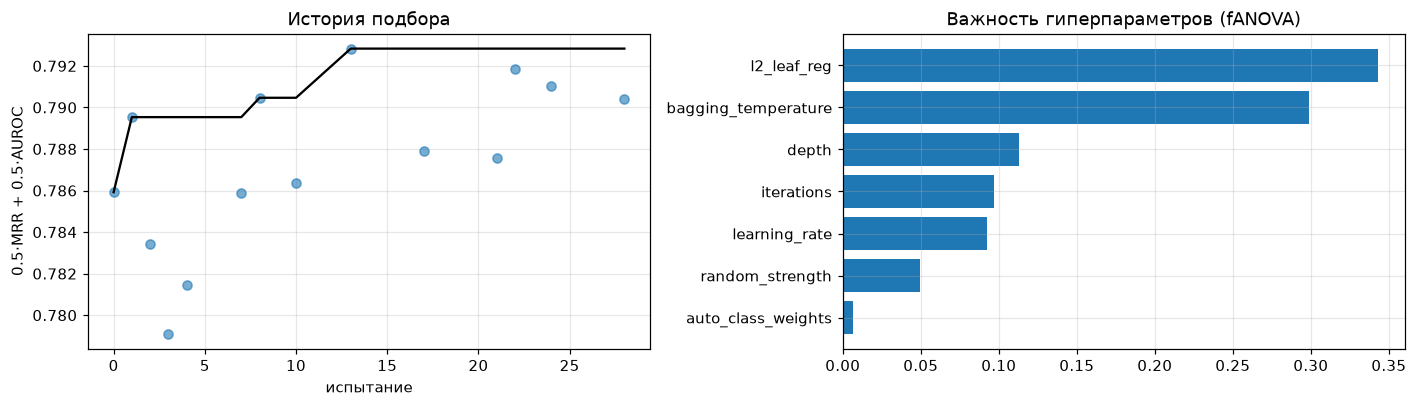

In [16]:
started = time.time()
final_study = tune(queries, COLS, TRIALS_FINAL, SEED + 100)
FINAL_PARAMS = final_study.best_params
print(f'подбор: {time.time() - started:.0f} s, лучший inner-score {final_study.best_value:.3f}')
params_table = pd.DataFrame({
    'текущие (боевые)': {**PRODUCTION, 'random_strength': 1.0, 'bagging_temperature': 1.0},
    'после подбора': FINAL_PARAMS}).astype(object)
changed = 'background-color: #fde0c5'
display(params_table.style.format(lambda v: f'{v:.3g}' if isinstance(v, float) else v)
        .apply(lambda row: [''] * 2 if row.iloc[0] == row.iloc[1] else [changed] * 2, axis=1))
trials = final_study.trials_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
done = trials[trials.state == 'COMPLETE']
axes[0].plot(done.number, done.value, 'o', alpha=.6)
axes[0].plot(done.number, done.value.cummax(), 'k-')
axes[0].set(title='История подбора', xlabel='испытание', ylabel='0.5·MRR + 0.5·AUROC')
try:
    importance = optuna.importance.get_param_importances(final_study)
    axes[1].barh(list(importance)[::-1], list(importance.values())[::-1])
    axes[1].set(title='Важность гиперпараметров (fANOVA)')
except RuntimeError as error:
    axes[1].set_title(f'importance недоступна: {error}')
plt.tight_layout(); plt.show()


слой,known,unknown-easy,unknown-hard,вин
роль,,,,
K,24,62,35,37
P,24,63,35,45
синтетика,300,0,0,300


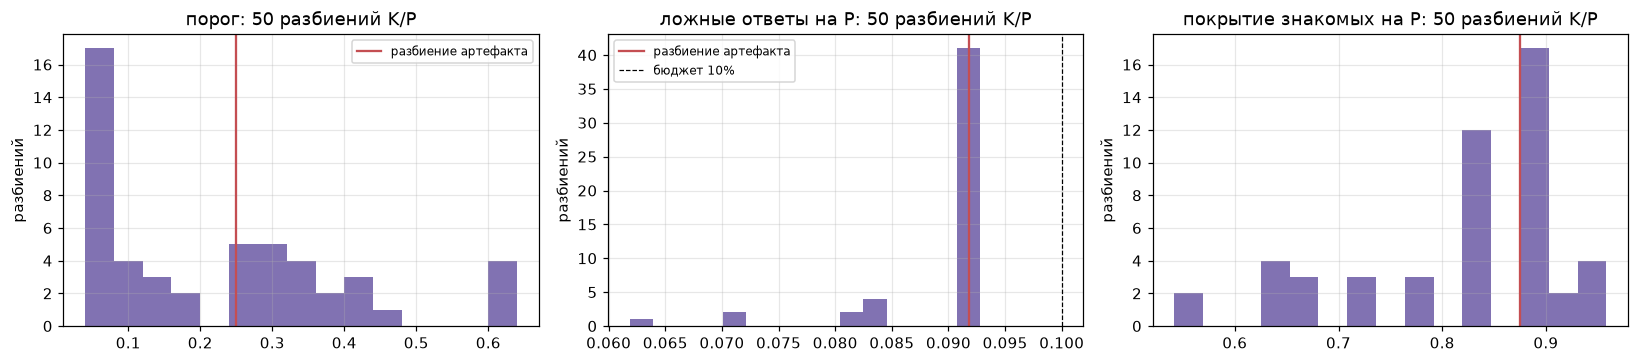

,count,mean,std,min,10%,50%,90%,max
threshold,50.000,0.220,0.175,0.040,0.050,0.160,0.413,0.640
false_answer_rate,50.000,0.090,0.006,0.062,0.082,0.092,0.093,0.093
coverage,50.000,0.812,0.107,0.542,0.625,0.833,0.917,0.958
precision,50.000,0.900,0.059,0.762,0.810,0.933,0.952,0.957


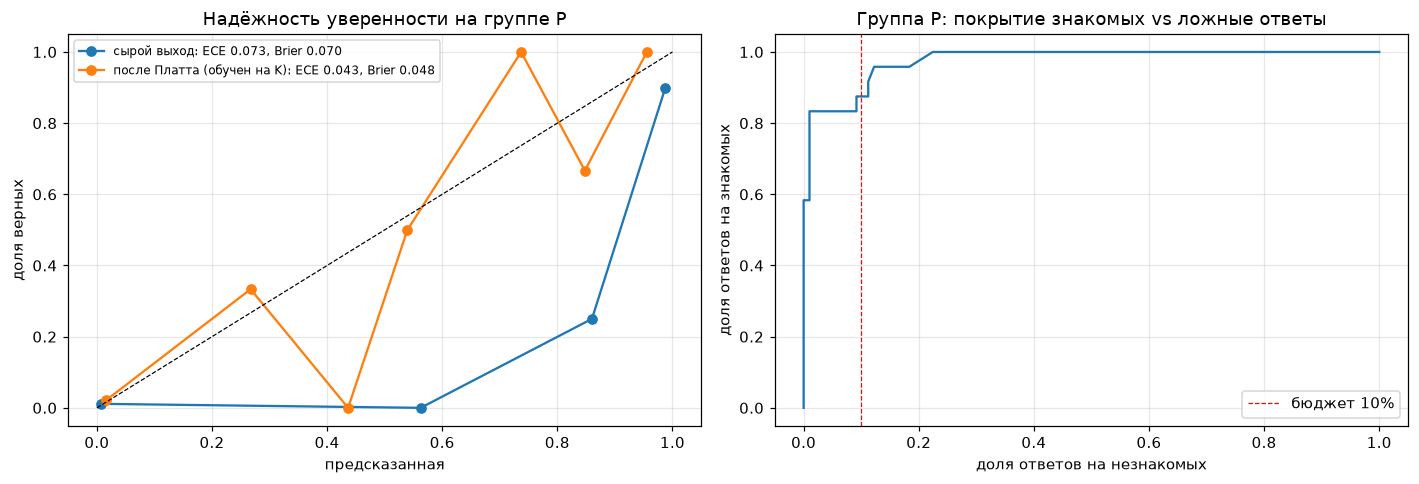

,OOF
threshold,0.250
coverage,0.875
precision,0.952
false_answer_rate,0.092
oof_top1_known,0.635
oof_top1_live_known,0.833


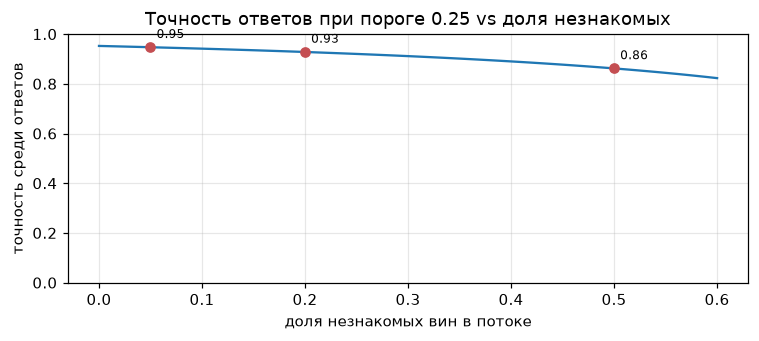

In [17]:
# OOF с финальными параметрами — материал для калибровки и порога.
final_folds = list(GroupKFold(5).split(queries, groups=wines_of[queries]))
n = len(queries)
oof_raw, oof_correct, oof_best = np.zeros(n), np.zeros(n, bool), [''] * n
for tr, te in final_folds:
    model = fit_catboost(FINAL_PARAMS, [queries[j] for j in tr], COLS)
    for j in te:
        q = queries[j]; p = model.predict_proba(FULL[q][:, COLS])[:, 1]; best = int(np.argmax(p))
        oof_raw[j], oof_correct[j] = p[best], bool(LABELS[q][best])
        oof_best[j] = by_query[q][best].item_id
known = Q.known.to_numpy()
wines_list, groups_list = Q.wine.tolist(), Q.group.tolist()
roles = TD.split_live(wines_list, known, groups_list, SEED)
split = TD.split_calibration(oof_raw, oof_correct, known, roles, BUDGET)
weight, bias = split['calib_weight'], split['calib_bias']
probe_decider = Decider(booster=None, calib_weight=weight, calib_bias=bias, threshold=0.0,
                        feature_names=tuple(FEATURE_NAMES[i] for i in COLS))
calibrated = probe_decider.calibrate(oof_raw)
P = roles == 'P'

composition = pd.crosstab(pd.Series(roles, name='роль').replace('', 'синтетика'),
                          pd.Series([TD.live_stratum(bool(k), g)
                                     for k, g in zip(known, groups_list)], name='слой'))
composition['вин'] = pd.Series(Q.wine.to_numpy()).groupby(
    pd.Series(roles).replace('', 'синтетика').to_numpy()).nunique()
display(styled(composition, bars=list(composition.columns)))

repeats = pd.DataFrame([
    TD.split_calibration(oof_raw, oof_correct, known,
                         TD.split_live(wines_list, known, groups_list, seed), BUDGET)
    for seed in range(SEED, SEED + SPLIT_REPEATS)])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, column, title in zip(axes, ('threshold', 'false_answer_rate', 'coverage'),
                             ('порог', 'ложные ответы на P', 'покрытие знакомых на P')):
    ax.hist(repeats[column], bins=15, color='#8172B2')
    ax.axvline(split[column], color='#C44E52', lw=1.5, label='разбиение артефакта')
    ax.set(title=f'{title}: {SPLIT_REPEATS} разбиений K/P', ylabel='разбиений')
axes[1].axvline(BUDGET, color='k', ls='--', lw=.8, label=f'бюджет {BUDGET:.0%}')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(styled(repeats[['threshold', 'false_answer_rate', 'coverage', 'precision']]
               .describe(percentiles=[.1, .5, .9]).T, precision=3))

def ece(p, y, bins=10):
    edges = np.linspace(0, 1, bins + 1); total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & (p < hi) if hi < 1 else (p >= lo)
        if m.any(): total += m.mean() * abs(p[m].mean() - y[m].mean())
    return total

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for p, label in ((oof_raw[P], 'сырой выход'), (calibrated[P], 'после Платта (обучен на K)')):
    y = oof_correct[P]
    edges = np.linspace(0, 1, 11); mids, rates = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & (p <= hi)
        if m.sum() >= 3: mids.append(p[m].mean()); rates.append(y[m].mean())
    axes[0].plot(mids, rates, 'o-', label=f'{label}: ECE {ece(p, y):.3f}, '
                 f'Brier {np.mean((p - y) ** 2):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=.8)
axes[0].set(title='Надёжность уверенности на группе P', xlabel='предсказанная',
            ylabel='доля верных'); axes[0].legend(fontsize=8)

thresholds = np.arange(0, 1, .01)
coverage = [(calibrated[P & known] >= t).mean() for t in thresholds]
false_answer = [(calibrated[P & ~known] >= t).mean() for t in thresholds]
axes[1].plot(false_answer, coverage, '-')
axes[1].axvline(BUDGET, color='r', ls='--', lw=.8, label=f'бюджет {BUDGET:.0%}')
axes[1].set(title='Группа P: покрытие знакомых vs ложные ответы',
            xlabel='доля ответов на незнакомых', ylabel='доля ответов на знакомых')
axes[1].legend()
plt.tight_layout(); plt.show()

picked = {k: split[k] for k in ('threshold', 'coverage', 'precision', 'false_answer_rate')}
threshold_table = pd.Series({**picked, 'oof_top1_known': oof_correct[known].mean(),
                             'oof_top1_live_known': oof_correct[known & Q.group.str.startswith(
                                 'live-').to_numpy()].mean()}, name='OOF').to_frame()
display(styled(threshold_table, precision=3))
shares = np.linspace(0, .6, 61)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(shares, [TD.precision_at_prior(picked, s) for s in shares])
for share in (0.05, 0.2, 0.5):
    v = TD.precision_at_prior(picked, share); ax.plot(share, v, 'o', color='#C44E52')
    ax.annotate(f'{v:.2f}', (share, v), textcoords='offset points', xytext=(4, 6), fontsize=8)
ax.set(title=f"Точность ответов при пороге {picked['threshold']:.2f} vs доля незнакомых",
       xlabel='доля незнакомых вин в потоке', ylabel='точность среди ответов', ylim=(0, 1))
plt.tight_layout(); plt.show()


### 5.1 Интерпретация

Важность считаем на строках, по которым модель реально принимает решение, — у **лидера
каждого запроса**: именно его уверенность сравнивается с порогом. SHAP-значения CatBoost
(`type='ShapValues'`) раскладывают логит уверенности по признакам. Напоминание из 2.5:
у коррелированных дублей важность делится, по одному признаку выводы не делаем.


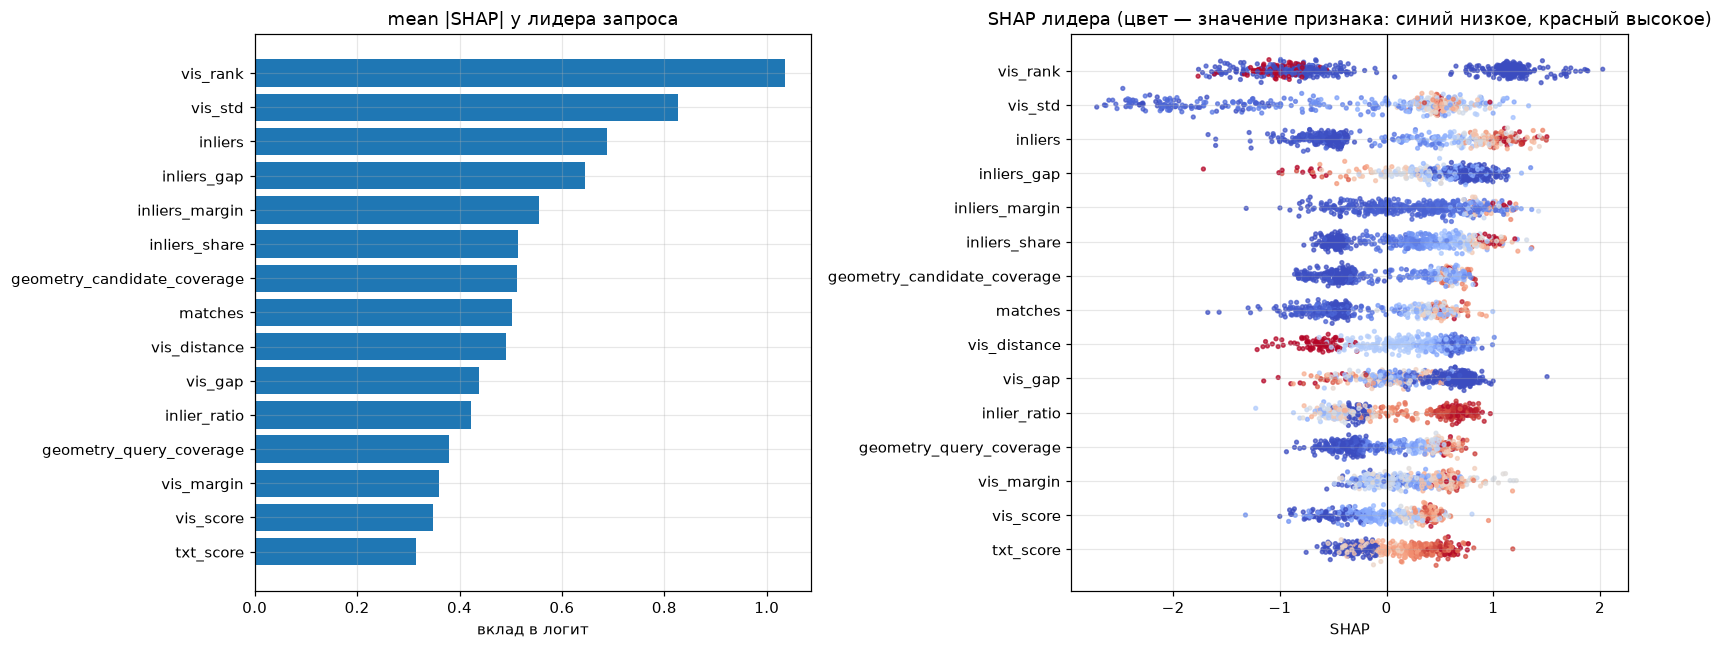

In [18]:
final_model = fit_catboost(FINAL_PARAMS, queries, COLS)
names = [FEATURE_NAMES[i] for i in COLS]
def leader(q):
    x = FULL[q][:, COLS]
    return x[int(np.argmax(final_model.predict_proba(x)[:, 1]))]
leader_rows = np.vstack([leader(q) for q in queries])
shap = final_model.get_feature_importance(Pool(leader_rows), type='ShapValues')[:, :-1]
mean_abs = pd.Series(np.abs(shap).mean(0), index=names).sort_values(ascending=False)
top = list(mean_abs.index[:15])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top[::-1], mean_abs[top[::-1]])
axes[0].set(title='mean |SHAP| у лидера запроса', xlabel='вклад в логит')
for row, feature in enumerate(top[::-1]):
    i = names.index(feature); values = leader_rows[:, i]
    lo, hi = np.percentile(values, [2, 98])
    color = np.clip((values - lo) / (hi - lo + 1e-12), 0, 1)
    jitter = np.random.default_rng(row).normal(0, .12, len(values))
    axes[1].scatter(shap[:, i], row + jitter, c=color, cmap='coolwarm', s=6, alpha=.7)
axes[1].set_yticks(range(len(top)), top[::-1]); axes[1].axvline(0, color='k', lw=.8)
axes[1].set(title='SHAP лидера (цвет — значение признака: синий низкое, красный высокое)',
            xlabel='SHAP')
plt.tight_layout(); plt.show()


### 5.2 Разбор ошибок (OOF, train)

Где модель ошибается на знакомых винах и на каких незнакомых отвечает при выбранном пороге.
Ошибка «близнец» — выбран сосед той же винодельни: её визуальная ветка почти не различает,
и вся надежда на OCR-признаки.


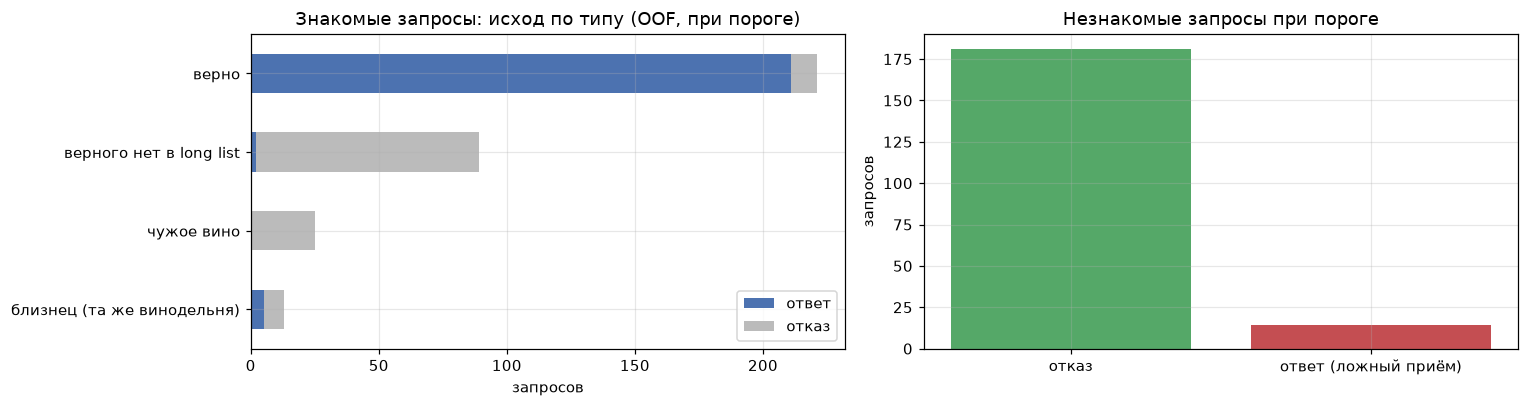

самые уверенные ошибки на знакомых:


,source,wine,predicted,confidence,same_winery,true_present
281,synthetic,vinogradniki-gay-kodzora-malbec-de-gai-kodzor-malbek-krasnoe-suhoe-135,vinogradniki-gay-kodzora-malbec-red-klen-de-gai-kodzor-malbek-krasnoe-suhoe-135,0.991,True,True
542,live-known,zhemchuzhnaya-9-aligote-czitron,zhemchuzhnaya-9-czitron-shardone,0.823,True,True
438,live-known,czitronnyj-magaracha,roze-2,0.774,True,True
99,synthetic,golubitskoe-estate-noble-selection-red-blend-kaberne-sovinon-krasnoe-suhoe-136,golubitskoe-estate-noble-selection-white-blend-shardone-beloe-suhoe-135,0.667,True,True
168,synthetic,polusladkoe-rozovoe-zolotaya-balka,abrau-dyurso-imperatorskoe-bryut-shardone-beloe-12,0.642,False,False
218,synthetic,usadba-divnomorskoe-marselan-marselan-krasnoe-suhoe-149,abrau-dyurso-imperatorskoe-bryut-shardone-beloe-12,0.435,False,False
467,live-known,rubin-golodrigi,bukovinka,0.288,True,True
18,synthetic,alma-valley-traminer-beloe-suhoe-125,abrau-dyurso-abrau-durso-brut-rose-reserve-pino-nuar-beloe-bryut-12,0.249,False,False
255,synthetic,vinodelnya-myshako-kaberne-sovinon-black-out-krasnoe-polusuhoe-16,balaklava-muskat-beloe-polusladkoe,0.246,False,False
297,synthetic,zolotaya-balka-zb-frizzante-semi-dry-rose-risling-rozovoe-polusuhoe-10,belmas-winery-viognier-belmas-vione-beloe-suhoe-122,0.231,False,False


незнакомых выше порога: 14 из 195


,source,wine,predicted,confidence
506,live-unknown,unknown:unknown-org-fanagoriya-alveus-ultra-kyuve-oranzh-bryut,fanagoriya-alveus-ultra-cuvee-brut-shardone-beloe-bryut-12,0.837
501,live-unknown,unknown:unknown-org-chateau-pinot-belenkoe-2025,shato-pino-gravitatsiya-kaberne-sovinon-merlo-krasnoe-suhoe-135,0.820
503,live-unknown,unknown:unknown-org-chateau-pinot-belenkoe-2025,shato-pino-gravitatsiya-kaberne-sovinon-merlo-krasnoe-suhoe-135,0.766
512,live-unknown,unknown:unknown-org-golubitskoe-estate-winery-series-red-blend,golubitskoe-estate-winery-series-roze-blend-kaberne-sovinon-rozovoe-suhoe-117,0.725
504,live-unknown,unknown:unknown-org-fanagoriya-alveus-ultra-kyuve-oranzh-bryut,fanagoriya-alveus-ultra-cuvee-brut-shardone-beloe-bryut-12,0.515
505,live-unknown,unknown:unknown-org-fanagoriya-alveus-ultra-kyuve-oranzh-bryut,fanagoriya-alveus-ultra-cuvee-brut-shardone-beloe-bryut-12,0.504
507,live-unknown,unknown:unknown-org-fanagoriya-alveus-ultra-kyuve-oranzh-bryut,fanagoriya-alveus-ultra-cuvee-brut-shardone-beloe-bryut-12,0.487
499,live-unknown,unknown:unknown-org-aya-khrustaleva-76-extra-brut-pinot-gris-2025,khrustaleva-76-muscat-bryut-beloe,0.421
397,live-unknown,unknown:Louis_Latour_Ardeche_Chardonnay_2023,chateau-andre-shardone-beloe-suhoe-13,0.416
398,live-unknown,unknown:Louis_Latour_Ardeche_Chardonnay_2023,chateau-andre-shardone-beloe-suhoe-13,0.406


In [19]:
errors = pd.DataFrame({'query': queries, 'wine': Q.wine, 'source': Q.source,
                       'predicted': oof_best, 'correct': oof_correct,
                       'confidence': calibrated, 'known': known})
errors['same_winery'] = [TD.FAMILIES.get(p) is not None and TD.FAMILIES.get(p) == TD.FAMILIES.get(w)
                         for p, w in zip(errors.predicted, errors.wine)]
errors['true_present'] = Q.true_present.to_numpy()
wrong = errors[errors.known & ~errors.correct]
answered = errors.confidence >= picked['threshold']
kind = pd.Series(np.select([errors.correct, ~errors.true_present, errors.same_winery],
                           ['верно', 'верного нет в long list', 'близнец (та же винодельня)'],
                           'чужое вино'), index=errors.index)
decision = pd.Series(np.where(answered, 'ответ', 'отказ'), index=errors.index)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
known_view = pd.crosstab(kind[errors.known], decision[errors.known])
known_view.loc[known_view.sum(axis=1).sort_values().index].plot.barh(
    stacked=True, ax=axes[0], color={'отказ': '#bbbbbb', 'ответ': '#4C72B0'})
axes[0].set(title='Знакомые запросы: исход по типу (OOF, при пороге)', xlabel='запросов',
            ylabel='')
axes[0].legend(title='')
unknown_answered = answered[~errors.known]
axes[1].bar(['отказ', 'ответ (ложный приём)'],
            [int((~unknown_answered).sum()), int(unknown_answered.sum())],
            color=['#55A868', '#C44E52'])
axes[1].set(title='Незнакомые запросы при пороге', ylabel='запросов')
plt.tight_layout(); plt.show()

show = ['source', 'wine', 'predicted', 'confidence', 'same_winery', 'true_present']
print('самые уверенные ошибки на знакомых:')
display(styled(wrong.sort_values('confidence', ascending=False).head(12)[show],
               bars=['confidence']))
accepted = errors[~errors.known & answered]
print(f'незнакомых выше порога: {len(accepted)} из {(~errors.known).sum()}')
display(styled(accepted.sort_values('confidence', ascending=False).head(12)
               [['source', 'wine', 'predicted', 'confidence']], bars=['confidence']))


### 5.3 Сохранение артефакта

Модель пишется в `models/decider_platform_sq_v3` тем же `Decider.save`, что и боевой скрипт,
вместе с OOF-предсказаниями; подбор и все CV-результаты — в
`eval/results/decider_tuning_sq_v3.json`.


In [20]:
decider = Decider(
    booster=final_model, calib_weight=weight, calib_bias=bias, threshold=picked['threshold'],
    feature_names=tuple(names),
    meta={'trained_on': str(FEATURES), 'index': str(INDEX), 'holdout_isolated': True,
          'preprocessing_version': LABEL_PREPROCESS_VERSION, 'feature_set': best_fs,
          'params': FINAL_PARAMS, 'queries': len(queries), 'wines': int(Q.wine.nunique()),
          'unknown_queries': int((~known).sum()), 'oof_top1': float(oof_correct[known].mean()),
          'scenario': 'real', 'calibration': 'live-split', 'live_split': split,
          'split_repeats': repeats[['threshold', 'false_answer_rate', 'coverage']]
          .describe().to_dict(), 'budget': BUDGET, 'live_weight': LIVE_WEIGHT,
          'augment_unknown': True, 'coverage': picked['coverage'],
          'precision': picked['precision'], 'false_answer_rate': picked['false_answer_rate'],
          'notebook': 'notebooks/06_decider_eda_and_training.ipynb'},
)
decider.save(OUT_DIR)
with (OUT_DIR/'oof_predictions.jsonl').open('w', encoding='utf-8') as stream:
    for i, q in enumerate(queries):
        stream.write(json.dumps({'query': q, 'wine': Q.wine[i], 'known': bool(known[i]),
                                 'best_id': oof_best[i], 'correct': bool(oof_correct[i]),
                                 'confidence_raw': float(oof_raw[i]),
                                 'calibrated': float(calibrated[i])}, ensure_ascii=False) + '\n')
TUNING_JSON.write_text(json.dumps({
    'features': str(FEATURES), 'feature_set': best_fs, 'seed': SEED,
    'objective': '0.5*MRR + 0.5*AUROC_real, inner GroupKFold(3) by wine',
    'nested_best_params': nested_params, 'final_params': FINAL_PARAMS,
    'final_inner_score': final_study.best_value,
    'outer_cv': {name: pooled_metrics(OOF[name]) for name in RESULTS},
    'threshold': picked, 'live_split': split,
    'split_repeats': repeats.to_dict(orient='list'),
}, ensure_ascii=False, indent=2, default=float), encoding='utf-8')
print('сохранено:', OUT_DIR, TUNING_JSON)


сохранено: models\decider_platform_sq_v3_live eval\results\decider_tuning_sq_v3_live.json


## 6. Проверка на изолированном тесте

Единственное обращение к `data/test`: тот же индекс v3, новый решающий слой, полный
`WineScanner` через `eval/platform_benchmark.py`. Сравнение — с прогоном того же индекса и
действующего `decider_platform_paddle` (тег `square-ab v3 ...` в `platform_runs.jsonl`).
По результату теста **ничего не подбирается**: если он хуже, возвращаемся к train, а не
двигаем порог по тесту.


In [21]:
TAG = 'notebook-06 live: organizer_100 in train, K/P split, index_platform_sq_v3'
started = time.time()
run = subprocess.run(
    [sys.executable, 'eval/platform_benchmark.py', '--index', str(INDEX), '--decider', str(OUT_DIR),
     '--tag', TAG, '--dump', 'eval/results/platform_sq_v3_live_outcomes.jsonl'],
    capture_output=True, text=True, encoding='utf-8', errors='replace',
    env={**os.environ, 'PYTHONIOENCODING': 'utf-8'})
print(f'benchmark: {time.time() - started:.0f} s, код {run.returncode}')
summary_lines = [l for l in run.stdout.splitlines()
                 if l.startswith(('визуальный ранг', 'текстовый ранг', 'в длинном', 'защита',
                                  'исходы', 'ложные'))]
print('\n'.join(summary_lines) if run.returncode == 0 else run.stderr[-3000:])


benchmark: 274 s, код 0
визуальный ранг верной   r@1:0.817  r@5:1.000  r@10:1.000  r@25:1.000  r@50:1.000  r@100:1.000
текстовый ранг верной    r@1:0.538  r@5:0.817  r@10:0.871  r@25:0.892  r@50:0.946
в длинном списке 1.000   в окне ре-ранкинга 0.989   лидер по инлаерам 0.699   итоговый top-1 0.860
защита сработала: на известных 3, на незнакомых 25; выбор внутри семьи по тексту: 8 / 23
исходы: верно 73, близнец 9, чужое 0, отказ 11  ->  точность среди ответов 0.890, покрытие 0.882
ложные приёмы незнакомых: unknown-hard 0.225 (102), all 0.225 (102)


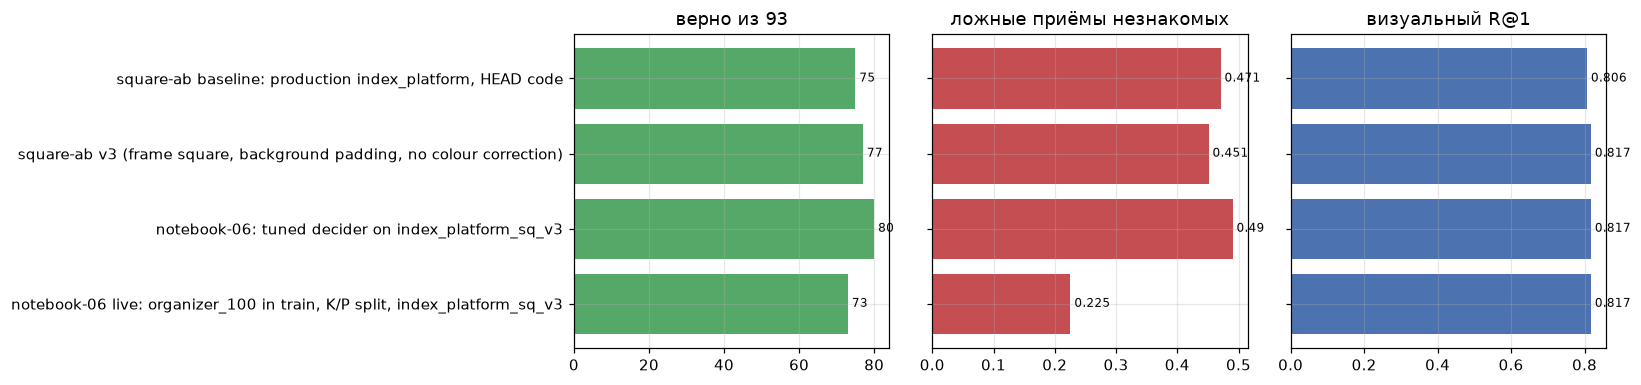

,верно из 93,близнец/чужое,отказ,точность ответов,визуальный R@1,ложные приёмы незнакомых
"square-ab baseline: production index_platform, HEAD code",75.000,15.000,3.000,0.833,0.806,0.471
"square-ab v3 (frame square, background padding, no colour correction)",77.000,15.000,1.000,0.837,0.817,0.451
notebook-06: tuned decider on index_platform_sq_v3,80.000,13.000,0.000,0.860,0.817,0.490
"notebook-06 live: organizer_100 in train, K/P split, index_platform_sq_v3",73.000,9.000,11.000,0.890,0.817,0.225


In [22]:
runs = [json.loads(l) for l in Path('eval/results/platform_runs.jsonl')
        .read_text(encoding='utf-8').splitlines()]
latest = {}
for r in runs:
    if r['tag'].startswith(('square-ab v3', 'square-ab baseline', 'notebook-06')):
        latest[r['tag']] = r['metrics']
table = pd.DataFrame({tag: {
    'верно из 93': m['slug_only']['answered_correct'],
    'близнец/чужое': m['slug_only']['wrong_or_twin'],
    'отказ': m['slug_only']['refused'],
    'точность ответов': m['answered_precision'],
    'визуальный R@1': m['visual']['r@1'],
    'ложные приёмы незнакомых': m['false_accept']['all']['rate'],
} for tag, m in latest.items()}).T
fig, axes = plt.subplots(1, 3, figsize=(15, .5 * len(table) + 1.6), sharey=True)
for ax, (column, color) in zip(axes, (('верно из 93', '#55A868'),
                                      ('ложные приёмы незнакомых', '#C44E52'),
                                      ('визуальный R@1', '#4C72B0'))):
    ax.barh(table.index, table[column].astype(float), color=color)
    for y, v in enumerate(table[column].astype(float)):
        ax.text(v, y, f' {v:.3g}', va='center', fontsize=8)
    ax.set_title(column)
axes[0].invert_yaxis()
plt.tight_layout(); plt.show()
display(styled(table, good=['верно из 93', 'точность ответов', 'визуальный R@1'],
               bad=['близнец/чужое', 'отказ', 'ложные приёмы незнакомых']))


**Как читать итог.** На тесте ~93 знакомых кадра на ~54 вина — разница меньше
5–6 кадров укладывается в шум (см. bootstrap в 4.2 для масштаба). Решение о замене
`WINE_DECIDER` принимается, если новая модель не хуже по верным ответам **и** не хуже по
ложным приёмам незнакомых; в противном случае действующий decider остаётся, а выводы
ноутбука — материал для следующей итерации (больше живых знакомых кадров в train).


## 7. Выводы (прогон 23.09.2026: organizer_100 в train, калибровка и порог на K/P)

**Данные.** 543 запроса train: 300 синтетических знакомых, 48 живых знакомых (42 кадра
organizer_100 на 32 вина и 6 кадров Chateau Tamagne), 195 живых незнакомых. Вина и файлы
теста в train не попали.

**Сдвиг признаков (2.6).** Теперь у нас есть живые знакомые кадры, и сдвиг раскладывается на
две части. `vis_std` почти не зависит от способа съёмки (SMD −0.36 между синтетикой и
живыми знакомыми) и сильно отличает знакомое вино от незнакомого (+2.64). Это настоящий
сигнал, а не отпечаток домена; вывод предыдущего прогона был ошибочным: тогда синтетику можно
было сравнить только с живыми незнакомыми, и два эффекта смешались. Доменный сдвиг есть у
`ocr_lines` (−0.62) и `txt_top1_score` (−0.52). Набор `v3-nodomain` (без `vis_std`,
`vis_mean`, `ocr_lines`) теряет в отказе: AUROC 0.894 против 0.925 у v3. Эти признаки
оставляем.

**Модели (внешняя CV по винам).**

| модель | top1_present | top1_live | AUROC_real |
|---|---|---|---|
| max vis_score | 0.772 | 0.833 | **0.946** |
| логистическая регрессия | 0.830 | 0.771 | 0.915 |
| CatBoost v3, текущие параметры | **0.853** | 0.854 | 0.925 |
| CatBoost v4, текущие параметры | **0.853** | **0.875** | 0.917 |
| CatBoost v3 после подбора | **0.853** | 0.833 | 0.925 |

Подбор гиперпараметров снова ничего не дал: лучшие параметры скачут между фолдами (depth
4–7, l2 2.5–17), а качество совпадает с текущими. Поверхность плоская; текущие параметры
оставляем.

**Калибровка и порог (K/P).** В каждой группе по 24 живых знакомых кадра и по ~98 незнакомых.
На 50 случайных разбиениях доля ложных ответов на P держится у бюджета (медиана 0.092), но сам
порог гуляет от 0.04 до 0.64 (медиана 0.16), а покрытие знакомых — от 0.54 до 0.96. Порог
плохо определён: 24 знакомых кадров для него мало.

**Тест (единственный прогон).** Тот же индекс v3, decider с порогом 0.25 от разбиения seed 2026:

| | действующий decider | новый (live, K/P) |
|---|---|---|
| верно из 93 | **77** | 73 |
| верный кандидат на первом месте | 77 | **80** |
| ответ «близнецом» | 15 | **9** |
| отказ на знакомых | 1 | 11 |
| точность ответов | 0.837 | **0.890** |
| ложные приёмы незнакомых | 0.451 | **0.225** |

Ложные приёмы незнакомых сократились **вдвое** (с 46 до 23 кадров из 102), ответов
«близнецом» стало на 6 меньше. Цена — 11 отказов на знакомых вместо 1: из них 7 кадров, где
верный кандидат стоял первым, но уверенность не дотянула до порога. Поэтому верных ответов
на 4 меньше, хотя ранжирование лучше (80 против 77). Впервые порог, выбранный по train,
переносится на живой тест: на P ложных ответов 9%, на тесте 22% — разрыв остался, но это уже
не 5% против 49%.

**Решение.** Формальное правило раздела 6 («не хуже и по верным ответам, и по ложным
приёмам») не выполнено: −4 верных ответа. Но это не ошибки, а отказы, и разница в пределах
шума теста (±5–6 кадров). Замена `WINE_DECIDER` на `models/decider_platform_sq_v3_live` —
решение за владельцем продукта: для закрытого каталога важнее покрытие, для открытого
(главный долг — ложные приёмы) — новая модель.

**Что дальше.**

1. Порог упирается в число живых знакомых кадров: нужно ≥80–100 знакомых вин вне теста
   (сейчас 33), по 1–2 кадра. Съёмка через `data/incoming`, вина теста не снимать.
2. 14 кадров organizer_100 со статусом `check` в `eval/results/organizer_100_import_review.csv`
   ждут решения человека; подтверждённые незнакомые добавляют трудных близнецов.
3. Самые уверенные ложные приёмы — «близнецы» каталога (Alveus Ultra Cuvée Оранж →
   Alveus брют, Chateau Pinot «Беленькое» → «Гравитация»). Их отделяет текст этикетки, а не
   визуальный поиск: следующий резерв — OCR-признаки различающих слов.
